# Set up conda
```
curl -O https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
bash ./Miniconda3-latest-Linux-x86_64.sh

source ~/.bashrc

conda config --add channels bioconda & /
conda config --add channels conda-forge & /
conda config --set channel_priority strict & /
conda create --name bio-prak & /
conda activate bio-prak
conda instapp python=3.13 -y
conda install viennarna=2.7.2 bedtools jupyterlab scipy matplotlib pandas biopython samtools fasta -y
```

# Initial Files:
- GCF_000001405.40_GRCh38.p14_genomic.fna.gz  
    - https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/001/405/GCF_000001405.40_GRCh38.p14/GCF_000001405.40_GRCh38.p14_genomic.fna.gz
    - Full FASTA Human Genome Sequence
- GCF_000001405.40_GRCh38.p14_genomic.gtf.gz
    - https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/001/405/GCF_000001405.40_GRCh38.p14/GCF_000001405.40_GRCh38.p14_genomic.gtf.gz
    - GTF Genome Region Annotations for all Chromosomes   
- hg38.m6A.gz
    - http://bioinformaticsscience.cn/rmbase/download.php
    - Group: Mammal
    - Genome: Homo Sapiens
    - Assembly: hg38
    - Mod Type: m6A
    - Bed File with m6A Modification annotations for all Chromosomes
    - `tar xpfvz data/original/hg38.m6A.tar.gz -O | gzip -c > data/original/hg38.m6A.gz`

All saved under /data/original

# Renamed Files:
- GCF_000001405.40_GRCh38.p14_genomic.fna.gz -> genome.fna.gz
- GCF_000001405.40_GRCh38.p14_genomic.gtf.gz -> annotated.gtf.gz
- hg38.m6A.gz -> modifications.bed.gz

# Single Chromosome Files:
- Filtered with:
    ```
    zcat modifications.bed.gz | grep chr8 | gzip -c > modifications.bed.chr8.gz
    zcat annotated.gtf.gz | grep NC_000008.11 | gzip -c > annotated_NC_000008.11.gtf.gz
    zcat genome.fna.gz | sed -n '/NC_000008/,/NC_/p' | head -n -1 | gzip -c > genome_NC_000008.11.fna.gz
    ```

In [1]:
import os
from src.files.files import get_files

files = get_files()
original_files = files.get_original_files()
filtered_files = files.get_filtered_files()

with original_files.get_genome_file().open_or_recompute() as fullFasta:
    with filtered_files.get_genome_file().open_or_recompute() as filteredFasta:
        fullFasta.seek(0, os.SEEK_END)
        filteredFasta.seek(0, os.SEEK_END)
        
        print("Fasta filtered from size:", fullFasta.tell(), "to size", filteredFasta.tell())

with original_files.get_annotations_file().open_or_recompute() as fullGtf:
    with filtered_files.get_annotations_file().open_or_recompute() as filteredGtf:
        fullLines = sum(1 for _ in fullGtf)
        filteredLines = sum(1 for _ in filteredGtf)

        print("Annotations filtered from", fullLines, "lines to", filteredLines, "lines")

with original_files.get_modifications_file().open_or_recompute() as fullBed:
    with filtered_files.get_modifications_file().open_or_recompute() as filteredBed:
        fullLines = sum(1 for _ in fullBed)
        filteredLines = sum(1 for _ in filteredBed)

        print("Modifications filtered from", fullLines, "lines to", filteredLines, "lines")

Fasta filtered from size: 3339739109 to size 146952938
Annotations filtered from 4727823 lines to 165373 lines
Modifications filtered from 882385 lines to 28408 lines


# Correct Chromosome Names:
```
zcat annotated_NC_000008.11.gtf.gz | sed 's/NC_000008.11/chr8/g' | gzip -c > annotated_chr8.gtf.gz
zcat genome_NC_000008.11.fna.gz | sed 's/NC_000008.11/chr8/g' | gzip -c > genome_chr8.fna.gz
```

# Bed12 Files:
```
mkdir software
cd software
git clone https://github.com/stephenfloor/extract-transcript-regions.git
```

```
mkdir data/hg38
python software/extract-transcript-regions/extract_transcript_regions.py --gtf -i data/annotated.gtf.gz -o data/hg38/hg38
```

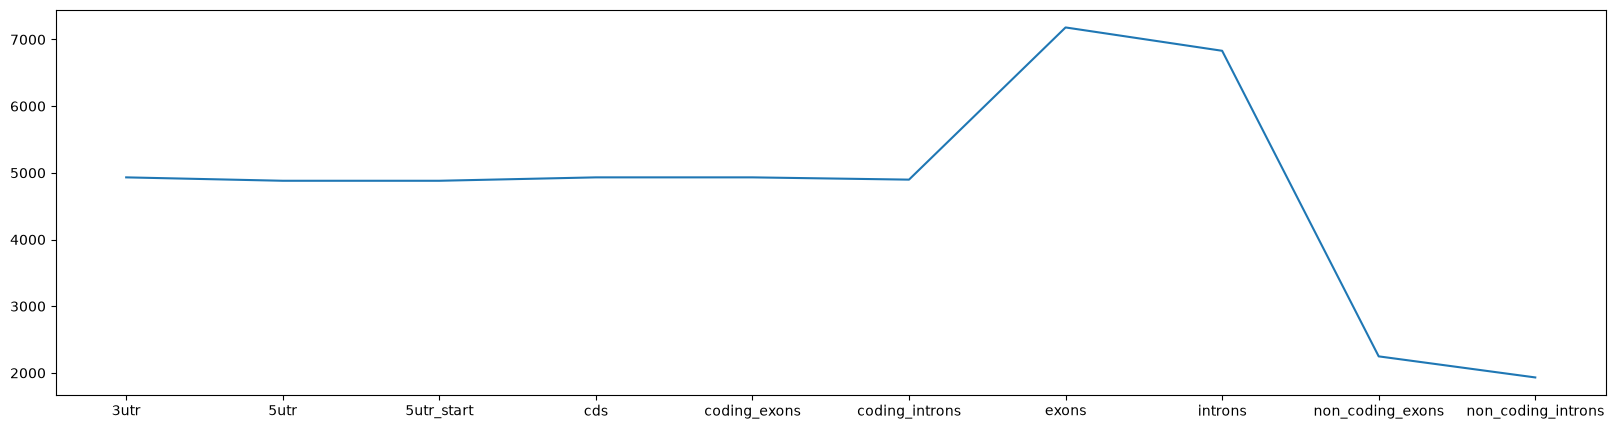

In [2]:
import matplotlib.pyplot as plt
from src.files.files import get_files

line_counts = {}

for key, file in get_files().get_assembled_region_files().get_files_dict().items():
    line_counts[key] = sum(1 for _ in file.open_or_recompute())

fig, axs = plt.subplots(figsize=(20, 5))
axs.plot(line_counts.keys(), line_counts.values())
plt.show()

# Bgzip Fasta for getfasta
```
zcat data/genome_chr8.fna.gz | bgzip -c > data/genome_chr8.fna.bgz
```

# GetFasta
```
bedtools getfasta -s -split -fi data/genome_chr8.fna.bgz -bed data/hg38/hg38_3utr.bed -name | gzip -c > data/hg38/fasta/hg38_3utr.fna.gz
bedtools getfasta -s -split -fi data/genome_chr8.fna.bgz -bed data/hg38/hg38_5utr.bed -name | gzip -c > data/hg38/fasta/hg38_5utr.fna.gz
bedtools getfasta -s -split -fi data/genome_chr8.fna.bgz -bed data/hg38/hg38_5utr_start.bed -name | gzip -c > data/hg38/fasta/hg38_5utr_start.fna.gz
bedtools getfasta -s -split -fi data/genome_chr8.fna.bgz -bed data/hg38/hg38_cds.bed -name | gzip -c > data/hg38/fasta/hg38_cds.fna.gz
bedtools getfasta -s -split -fi data/genome_chr8.fna.bgz -bed data/hg38/hg38_codingexons.bed -name | gzip -c > data/hg38/fasta/hg38_codingexons.fna.gz
bedtools getfasta -s -split -fi data/genome_chr8.fna.bgz -bed data/hg38/hg38_codingintrons.bed -name | gzip -c > data/hg38/fasta/hg38_codingintrons.fna.gz
bedtools getfasta -s -split -fi data/genome_chr8.fna.bgz -bed data/hg38/hg38_exons.bed -name | gzip -c > data/hg38/fasta/hg38_exons.fna.gz
bedtools getfasta -s -split -fi data/genome_chr8.fna.bgz -bed data/hg38/hg38_introns.bed -name | gzip -c > data/hg38/fasta/hg38_introns.fna.gz
bedtools getfasta -s -split -fi data/genome_chr8.fna.bgz -bed data/hg38/hg38_noncodingexons.bed -name | gzip -c > data/hg38/fasta/hg38_noncodingexons.fna.gz
bedtools getfasta -s -split -fi data/genome_chr8.fna.bgz -bed data/hg38/hg38_noncodingintrons.bed -name | gzip -c > data/hg38/fasta/hg38_noncodingintrons.fna.gz
```

# Intersects
```
intersectBed -a data/hg38/hg38_3utr.bed -b data/modifications_chr8.bed.gz -s -split | gzip -c > data/hg38/intersect/hg38_3utr_intersect.bed.gz
intersectBed -a data/hg38/hg38_5utr.bed -b data/modifications_chr8.bed.gz -s -split | gzip -c > data/hg38/intersect/hg38_5utr_intersect.bed.gz
intersectBed -a data/hg38/hg38_5utr_start.bed -b data/modifications_chr8.bed.gz -s -split | gzip -c > data/hg38/intersect/hg38_5utr_start_intersect.bed.gz
intersectBed -a data/hg38/hg38_cds.bed -b data/modifications_chr8.bed.gz -s -split | gzip -c > data/hg38/intersect/hg38_cds_intersect.bed.gz
intersectBed -a data/hg38/hg38_codingexons.bed -b data/modifications_chr8.bed.gz -s -split | gzip -c > data/hg38/intersect/hg38_codingexons_intersect.bed.gz
intersectBed -a data/hg38/hg38_codingintrons.bed -b data/modifications_chr8.bed.gz -s -split | gzip -c > data/hg38/intersect/hg38_codingintrons_intersect.bed.gz
intersectBed -a data/hg38/hg38_exons.bed -b data/modifications_chr8.bed.gz -s -split | gzip -c > data/hg38/intersect/hg38_exons_intersect.bed.gz
intersectBed -a data/hg38/hg38_introns.bed -b data/modifications_chr8.bed.gz -s -split | gzip -c > data/hg38/intersect/hg38_introns_intersect.bed.gz
intersectBed -a data/hg38/hg38_noncodingexons.bed -b data/modifications_chr8.bed.gz -s -split | gzip -c > data/hg38/intersect/hg38_noncodingexons_intersect.bed.gz
intersectBed -a data/hg38/hg38_noncodingintrons.bed -b data/modifications_chr8.bed.gz -s -split | gzip -c > data/hg38/intersect/hg38_noncodingintrons_intersect.bed.gz
```

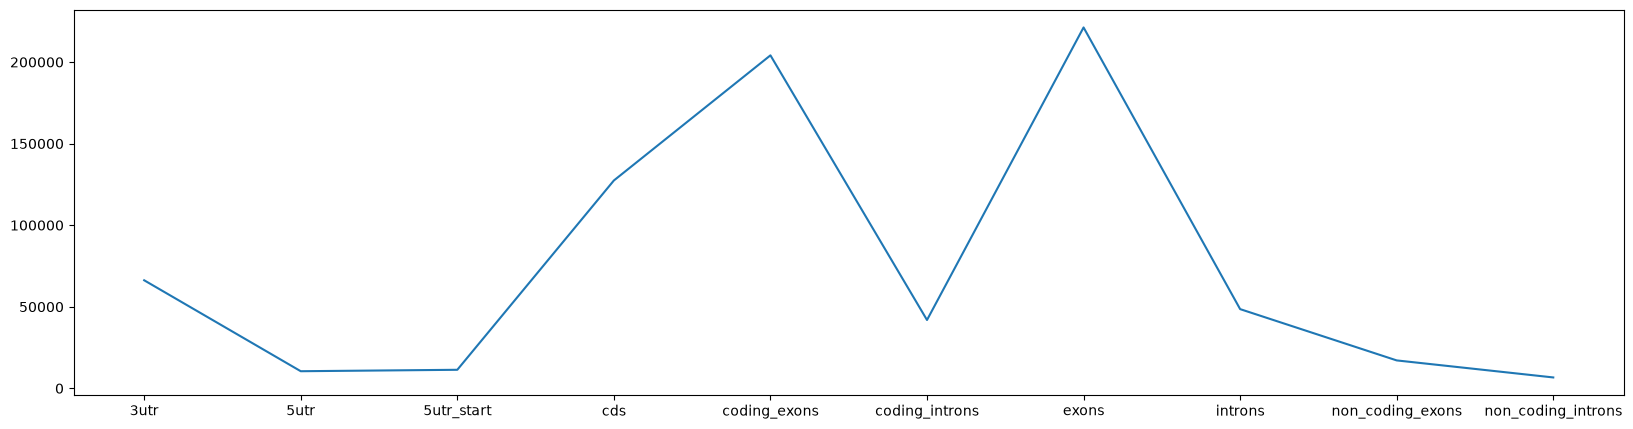

In [4]:
import matplotlib.pyplot as plt
from src.files.files import get_files

line_counts = {}

for key, file in get_files().get_assembled_region_intersects_files().get_files_dict().items():
    line_counts[key] = sum(1 for _ in file.open_or_recompute())

fig, axs = plt.subplots(figsize=(20, 5))
axs.plot(line_counts.keys(), line_counts.values())
plt.show()

# Make local intersects:

# Assemble Modifications



# Sanity Check
Testen, ob alle m6A modification positionen auch A sind

In [1]:
import gzip
import re
import csv
from src.util import load_region_modifications
from src.files.files import get_files

def sanity_check(fastaFile, regions):
    with fastaFile.open_or_recompute() as fastaFile:
        is_in_region = False
        has_region_modifications = False
        current_region_name = None
        current_region_modifications = None
        
        for line in fastaFile:
            if re.search(">", line):
                first_colon = line.find(":")
                
                is_in_region = True
                current_region_name = line[1:first_colon]
                current_region_modifications = []
                has_region_modifications = False
                if current_region_name in regions:
                    current_region_modifications = regions[current_region_name].modifications
                    if len(current_region_modifications):
                        has_region_modifications = True
            else:
                if not is_in_region:
                    continue
                if not has_region_modifications:
                    continue
                line_length = len(line)

                for modification in current_region_modifications:
                    if modification > line_length:
                        break

                    char = line[modification]

                    if char != "A" and char != "a":
                        print("Non A m6A!")

                current_region_modifications = filter(lambda modification: modification > line_length, current_region_modifications)
                current_region_modifications = [x - line_length for x in current_region_modifications]
                if len(current_region_modifications) == 0:
                    has_region_modifications = False

for key, file in get_files().get_assembled_region_local_intersects_assembled_files().get_files_dict().items():
    print("Checking", key)
    regions = load_region_modifications(file)

    sanity_check(get_files().get_assembled_region_fasta_files().get_files_dict()[key], regions)

print("Done")

Checking 3utr
Checking 5utr
Checking 5utr_start
Checking cds
Checking coding_exons
Checking coding_introns
Checking exons
Checking introns
Checking non_coding_exons
Checking non_coding_introns
Done


Calculating 3utr
Calculating 5utr
Calculating 5utr_start
Calculating cds
Calculating coding_exons
Calculating coding_introns
Calculating exons
Calculating introns
Calculating non_coding_exons
Calculating non_coding_introns


/tmp/ipykernel_331040/2875267982.py:56: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


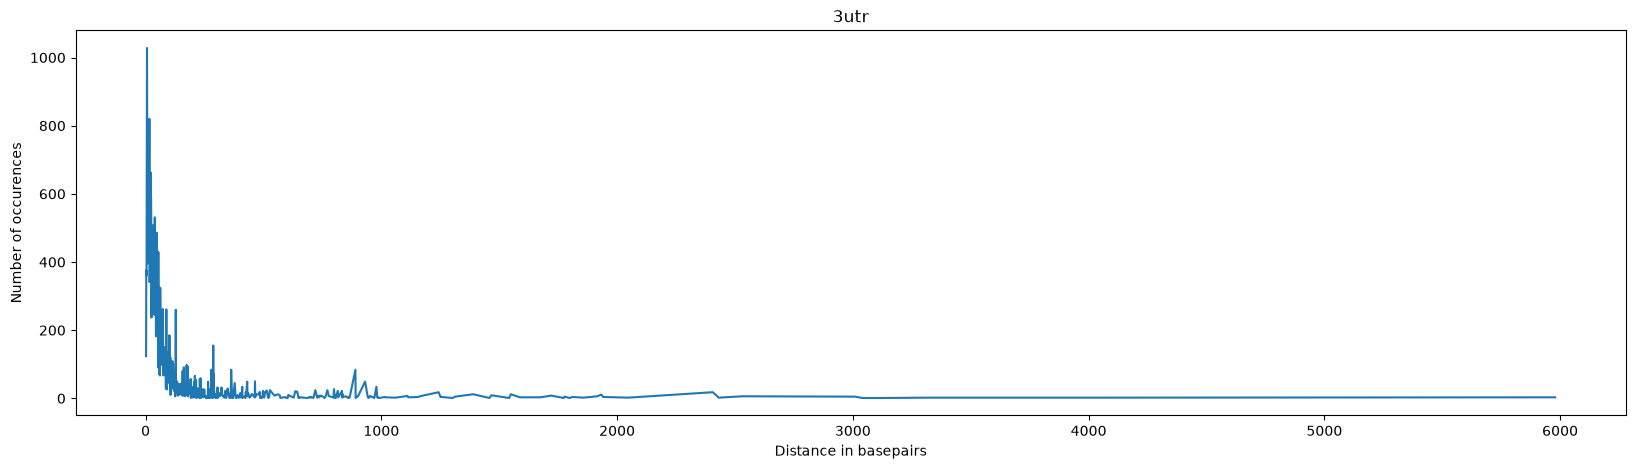

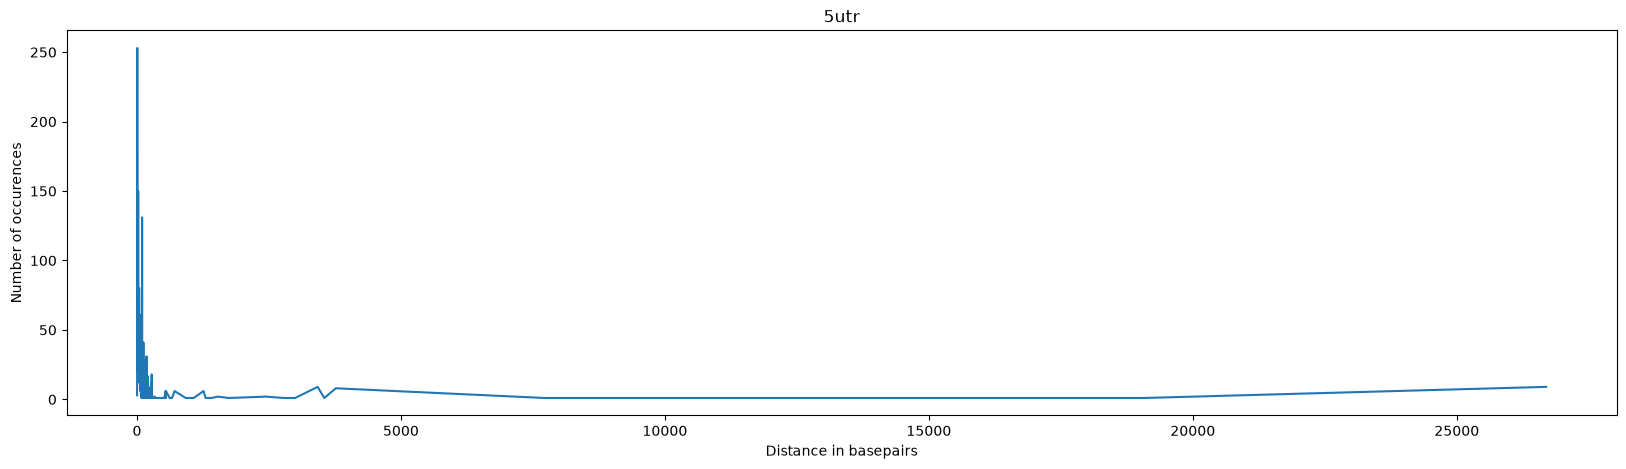

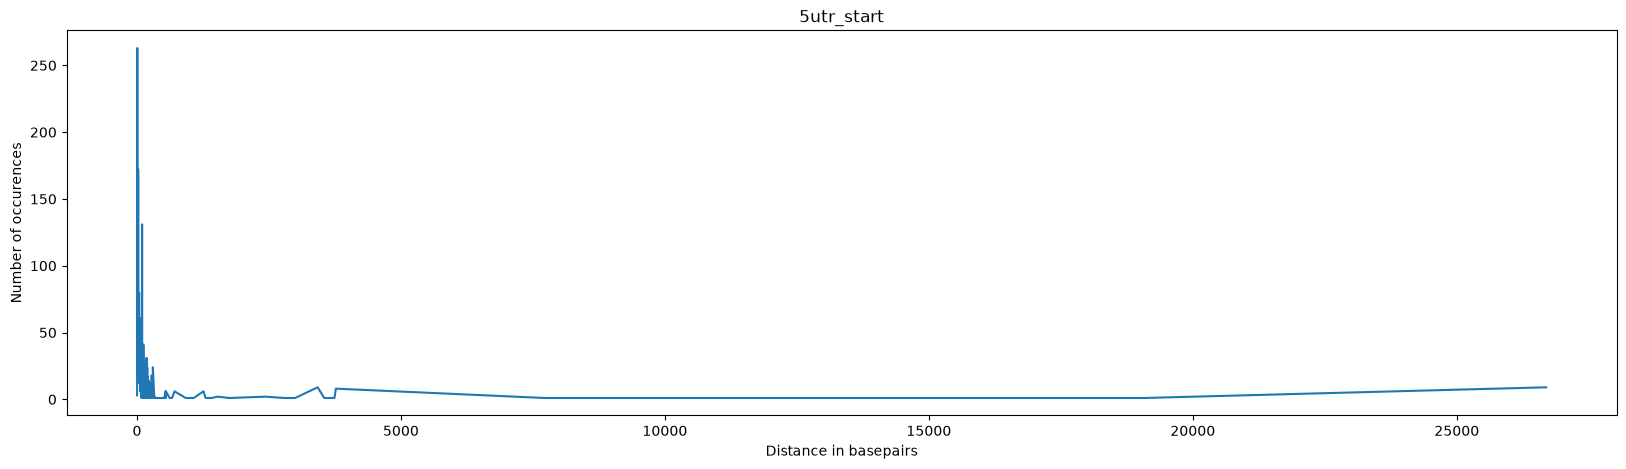

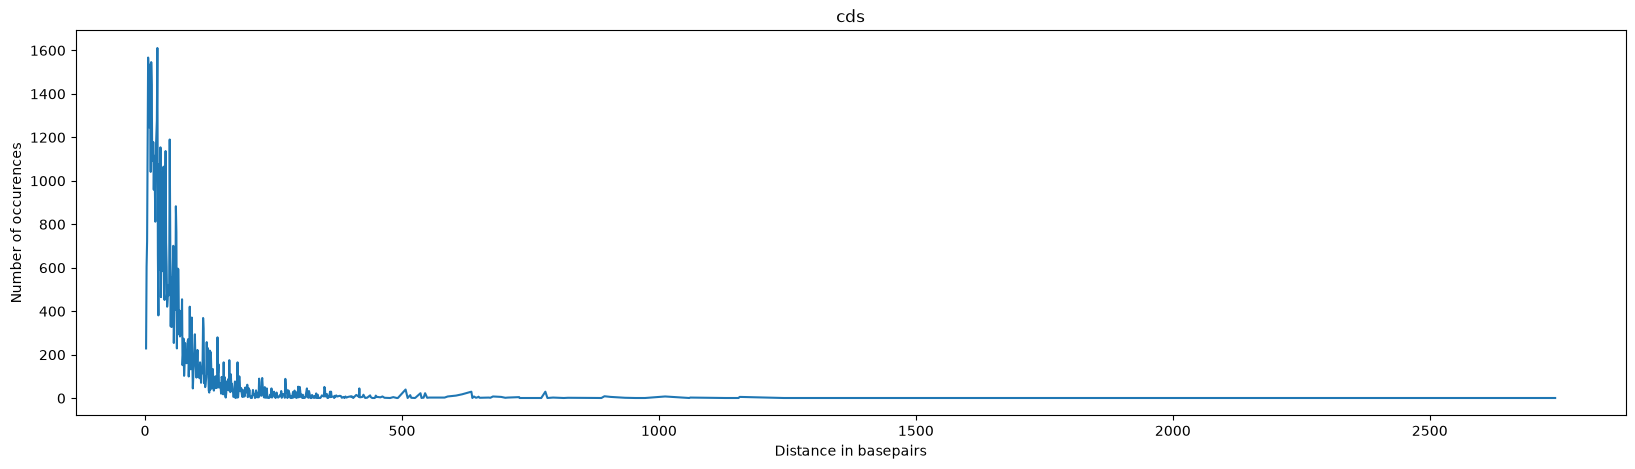

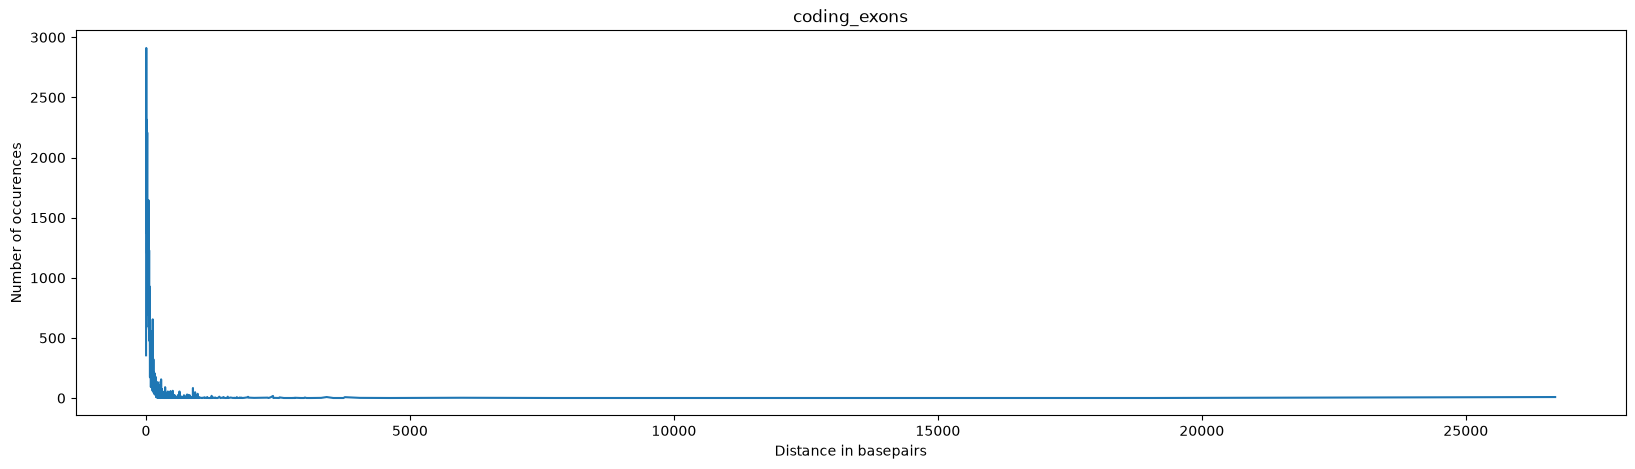

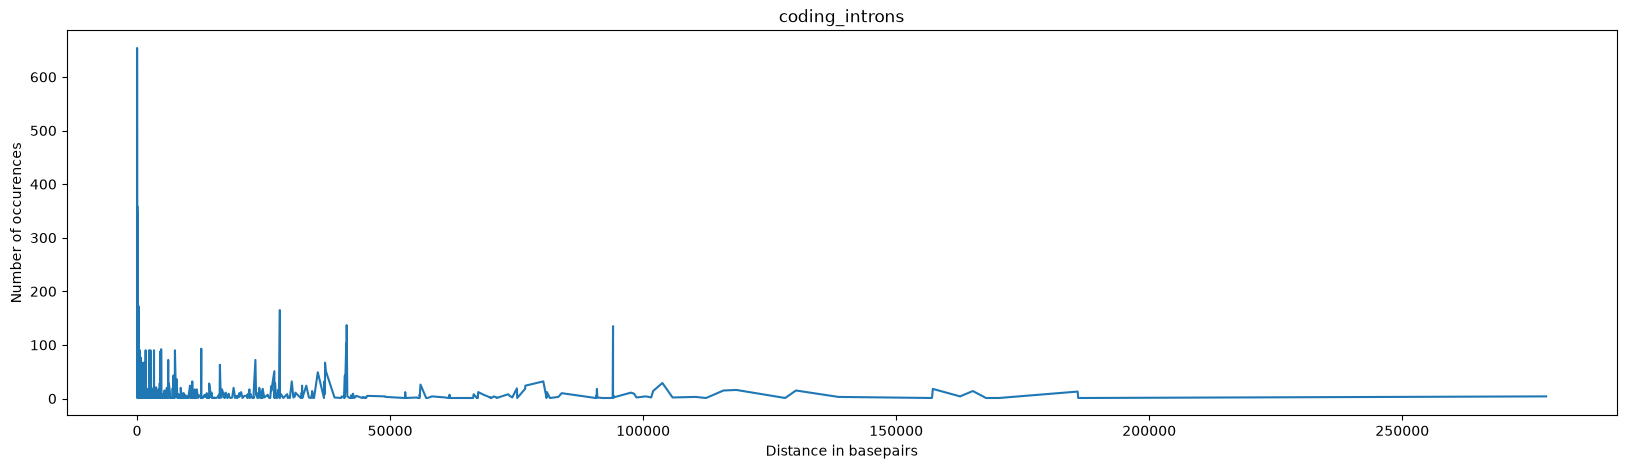

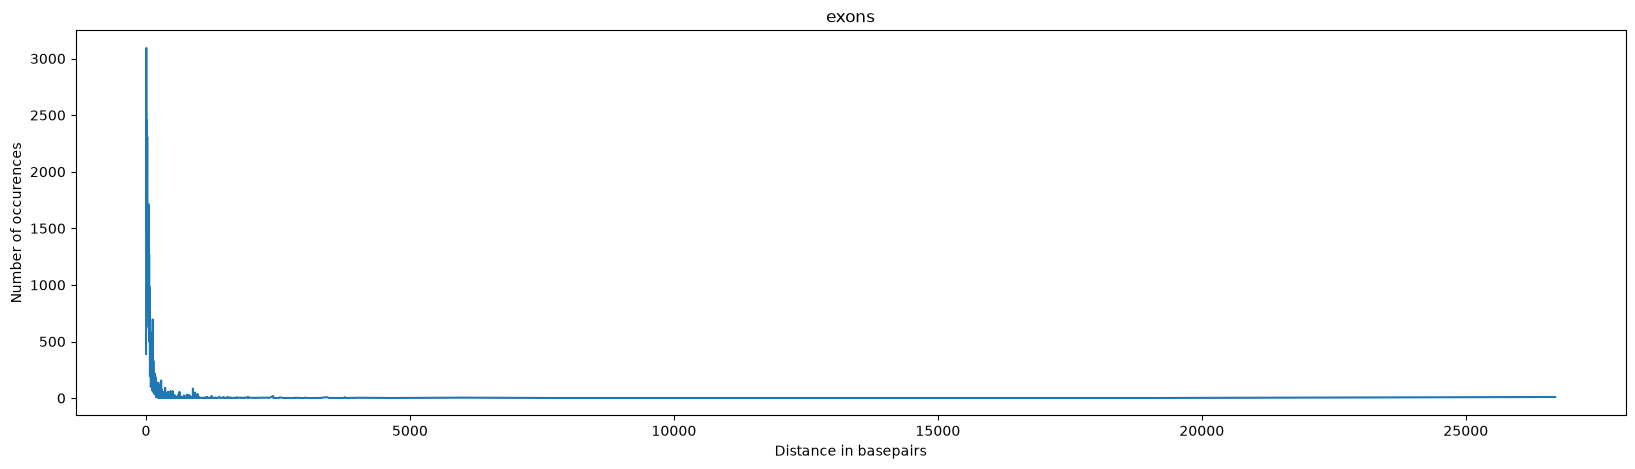

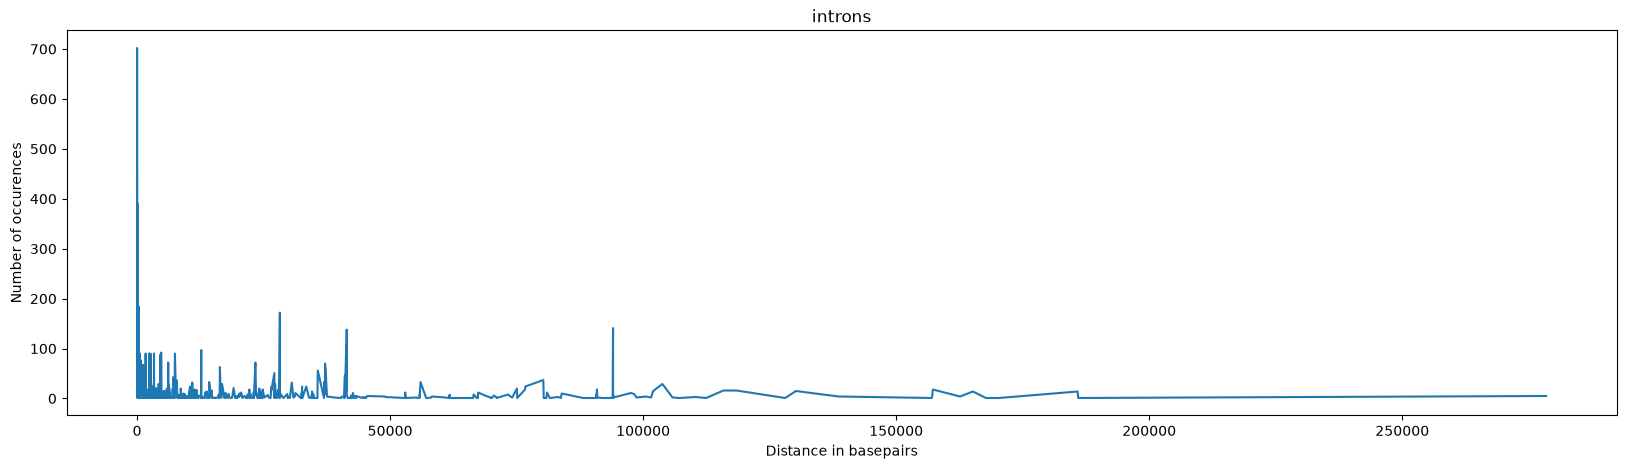

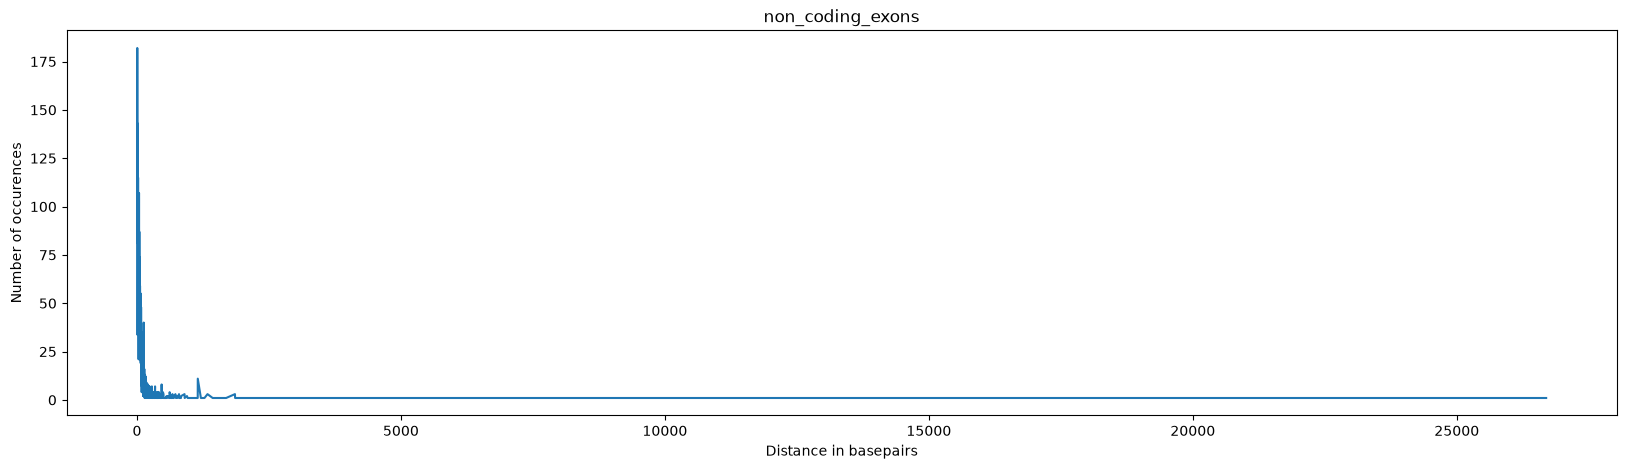

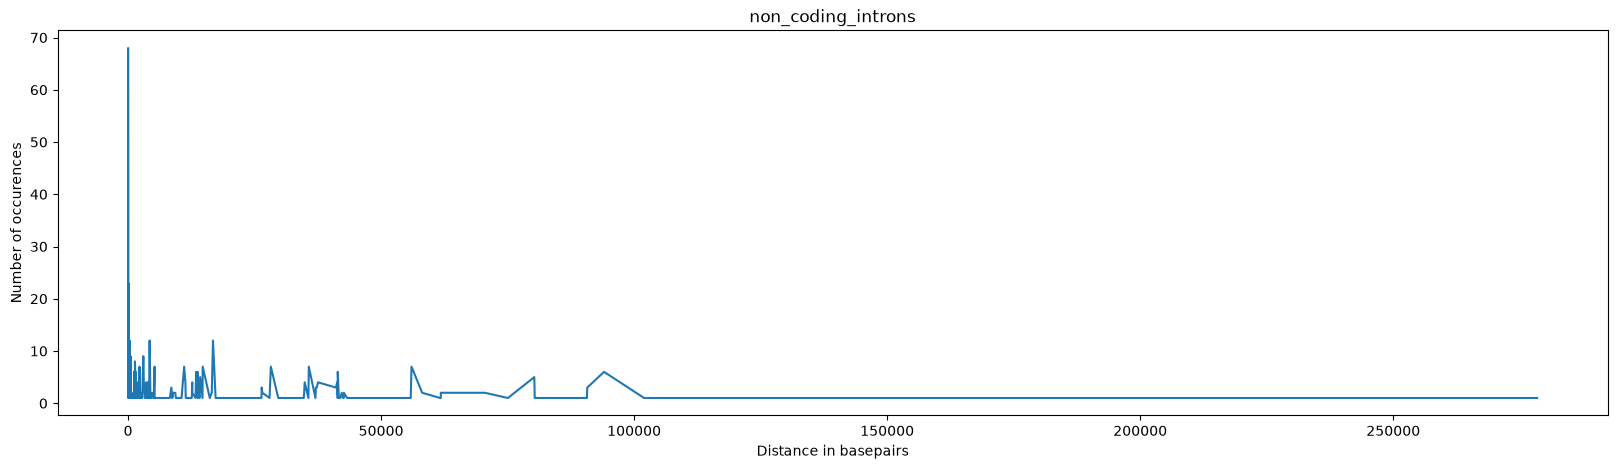

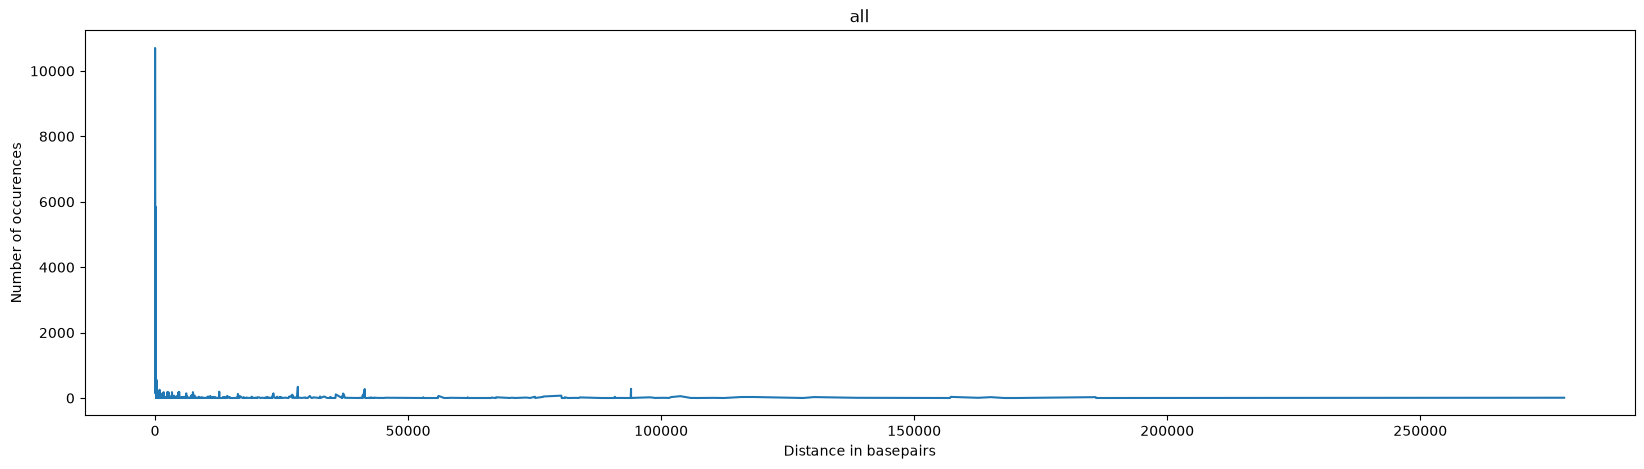

In [3]:
from src.util import load_region_modifications
from src.files.files import get_files
import matplotlib.pyplot as plt

distances = {}

def compute_modification_distances(regions):
    local_distances = {}
    
    for region in regions.values():
        modifications = region.modifications

        if len(modifications) < 2:
            continue

        for i in range(len(modifications) - 1):
            first = modifications[i]
            second = modifications[i + 1]

            distance = second - first

            if distance in local_distances:
                local_distances[distance] = local_distances[distance] + 1
            else:
                local_distances[distance] = 1

    return local_distances

for key, file in get_files().get_assembled_region_local_intersects_assembled_files().get_files_dict().items():
    print("Calculating", key)
    regions = load_region_modifications(file)
    
    distances[key] = compute_modification_distances(regions)

all_key_distances = {}

for key in distances.keys():
    for distance in distances[key]:
        if distance in all_key_distances:
            all_key_distances[distance] = all_key_distances[distance] + distances[key][distance]
        else:
            all_key_distances[distance] = distances[key][distance]

distances["all"] = all_key_distances

for key in distances.keys():
    fig, axs = plt.subplots(figsize=(20, 5))
    axs.set_title(key)
    axs.set_xlabel("Distance in basepairs")
    axs.set_ylabel("Number of occurences")
    data_tuples = sorted(distances[key].items(), key=lambda data: data[0])
    data_x = [x[0] for x in data_tuples]
    data_y = [x[1] for x in data_tuples]
    axs.plot(data_x, data_y)

    fig.show()

# Accessibility

NM_178857.6_exon
8014
[1688, 1707, 1770, 2658, 5402, 5412, 5429]
1538
5579


/home/erik/bio-prak/mypython/plot.py:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


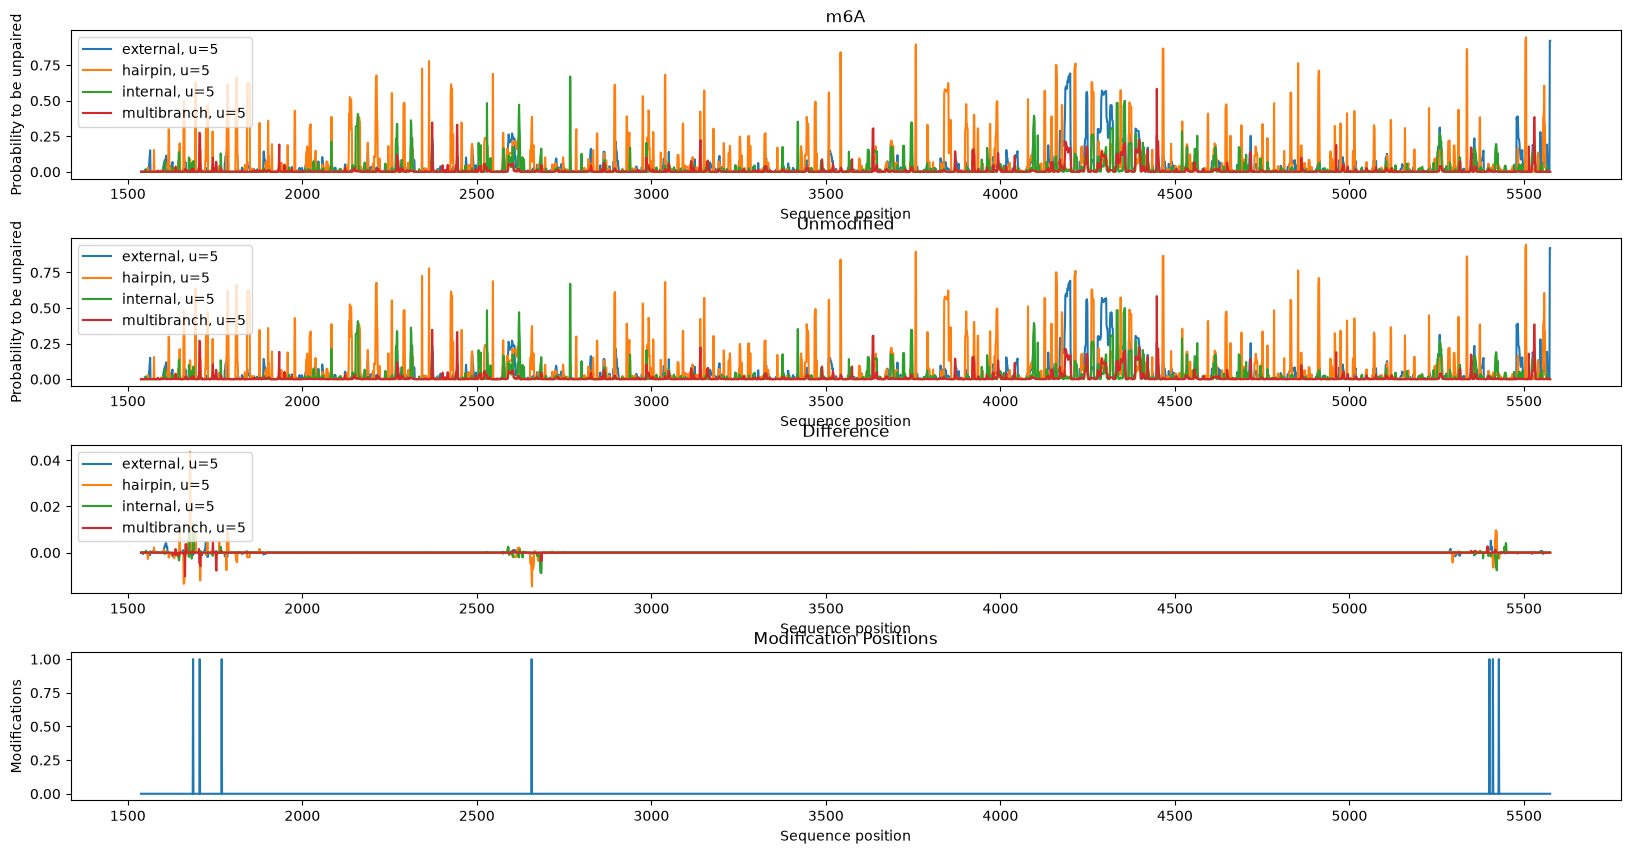

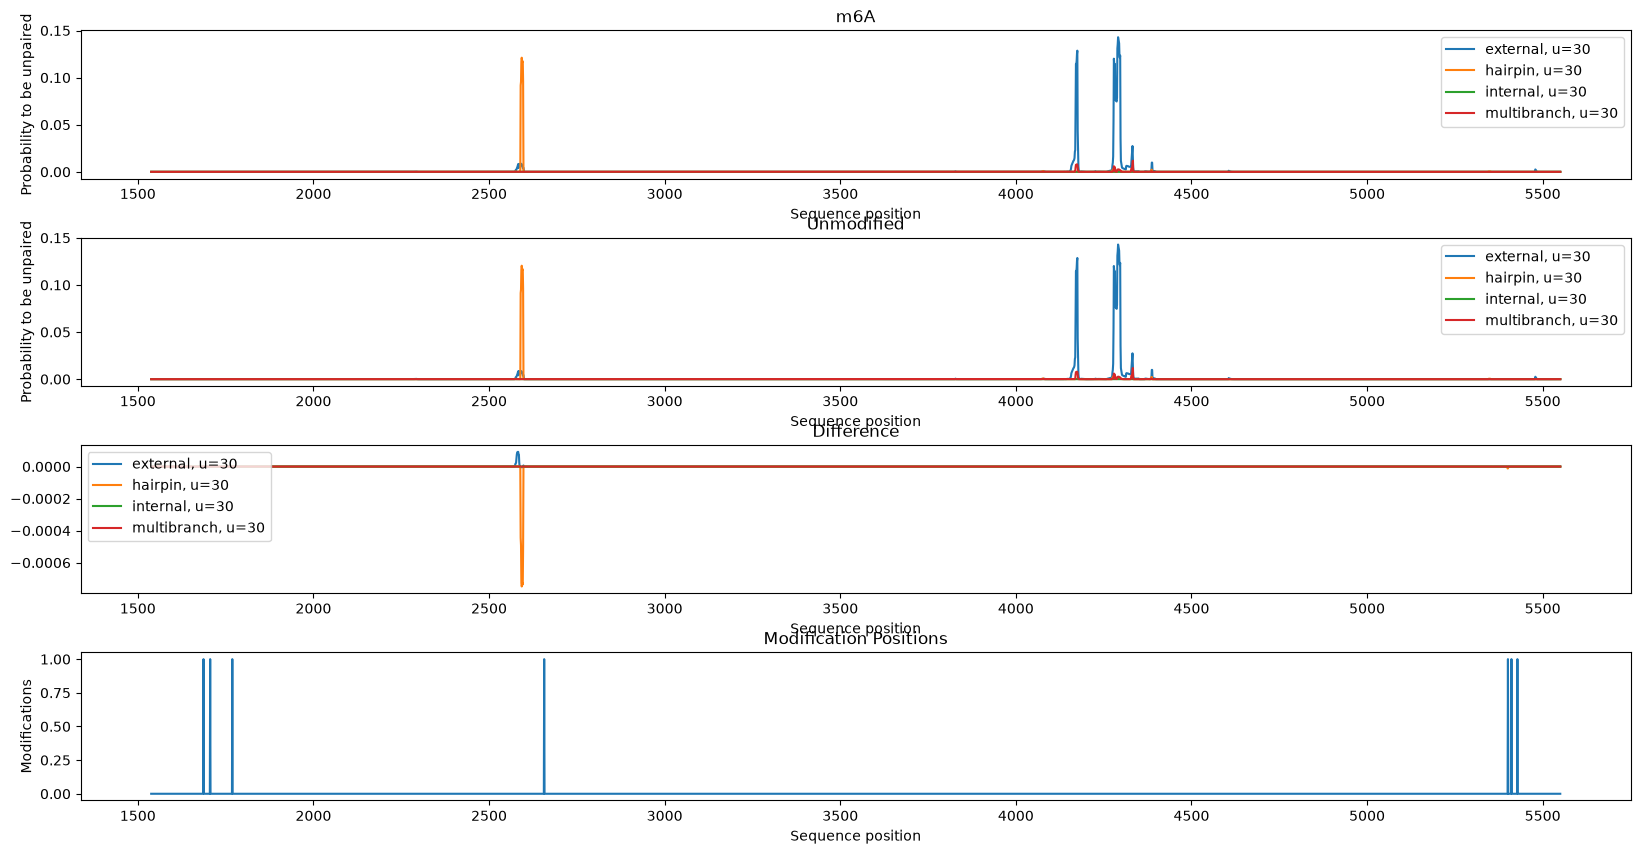

In [5]:
from mypython.algorithms import accessibility, looptypes
from mypython.plot import plot_accessibilities
from fasta import FASTA
from src.util import load_region_modifications
from src.files.files import get_files
import matplotlib.pyplot as plt

fastaFile = get_files().get_assembled_region_fasta_files().get_exons_file()
fastaFile.open_or_recompute()

file = FASTA(fastaFile.get_possibly_gzip_path())
regions = load_region_modifications(get_files().get_assembled_region_local_intersects_assembled_files().get_exons_file())

footprints = [5, 30]
windowsize = 150
L = 100

def map_entry(entry):
    region_name = entry.name[:entry.name.find(":")]
    sequence = str(entry.seq).upper().replace("T", "U")

    modifications = []
    
    if region_name in regions:
        modifications = regions[region_name].modifications

    return (region_name, sequence, modifications)

def filter_entry(entry):
    return len(entry[2]) != 0

def filter_length(entry):
    length = len(entry[1])
    return length > 8000 and length < 9000

modified_regions = filter(filter_length, filter(filter_entry, map(map_entry, file)))

for region_name, sequence, modifications in modified_regions:
    print(region_name)
    print(len(sequence))

    modifications = [x + 1 for x in modifications]
    print(modifications)

    start = max(0, modifications[0] - windowsize)
    end = min(len(sequence), modifications[len(modifications) - 1] + windowsize)

    sequence = sequence[start:end]
    modifications = [x - start for x in modifications]
    print(start)
    print(end)
    data_unmod = accessibility(sequence, footprints, windowsize = windowsize, L = L)
    data = accessibility(sequence, footprints, windowsize = windowsize, L = L, m6A_sites = modifications)

    plot_accessibilities(sequence, footprints, looptypes, start, end, data, data_unmod, modifications)
    break

# Window Accessibility

In [4]:
from mypython.algorithms import accessibility, looptypes
from mypython.plot import plot_accessibilities
from fasta import FASTA
from src.util import load_region_modifications
from src.files.files import get_files
import matplotlib.pyplot as plt

fastaFile = get_files().get_assembled_region_fasta_files().get_exons_file()
fastaFile.open_or_recompute()

file = FASTA(fastaFile.get_possibly_gzip_path())
regions = load_region_modifications(get_files().get_assembled_region_local_intersects_assembled_files().get_exons_file())

footprints = [5, 10, 15, 20, 25, 30]
windowsize = 150
L = 100

def map_entry(entry):
    region_name = entry.name[:entry.name.find(":")]
    sequence = str(entry.seq).upper().replace("T", "U")

    modifications = []
    
    if region_name in regions:
        modifications = [x + 1 for x in regions[region_name].modifications]

    return (region_name, sequence, modifications)

def filter_entry(entry):
    return len(entry[2]) != 0
    
modified_regions = list(filter(filter_entry, map(map_entry, file)))

num_modified_regions = len(modified_regions)

local_sequence_size = (2 * windowsize) - 1

accumulated_diff_data = {}

for footprint in footprints:
    f_data = {}
    for looptype in looptypes:
        f_data[looptype] = [0.0 for x in range(local_sequence_size - footprint + 2)]
    accumulated_diff_data[footprint] = f_data

print(num_modified_regions)
total_mods = 0
for region_name, sequence, modifications in modified_regions:
    for i in range(len(modifications)):
        if i > 0 and (modifications[i] - modifications[i - 1]) < windowsize:
            continue
        if i < (len(modifications) - 2) and (modifications[i + 1] - modifications[i]) < windowsize:
            continue

        modification = modifications[i]
        
        start = modification - windowsize

        if start < 0:
            continue

        end = modification + windowsize - 1

        if end > len(sequence):
            continue

        local_sequence = sequence[start:end]
        local_modification = [modification - start]
        
        local_data_unmod = accessibility(local_sequence, footprints, windowsize = windowsize, L = L)
        local_data = accessibility(local_sequence, footprints, windowsize = windowsize, L = L, m6A_sites = local_modification)

        for footprint in footprints:
            for looptype in local_data[footprint]:
                diff = [v for v in map(lambda pair: pair[1] - pair[0], zip(local_data[footprint][looptype], local_data_unmod[footprint][looptype]))]

                for i in range(len(diff)):
                    diff_value = diff[i]

                    accumulated_diff_data[footprint][looptype][i] += diff_value
        
        total_mods += 1

print(total_mods)


Copying data/original/GCF_000001405.40_GRCh38.p14_genomic.fna.gz to data/full/genome.fna.gz
Copying data/original/GCF_000001405.40_GRCh38.p14_genomic.fna.gz to data/full/genome.fna.gz done
Filtering fna data/full/genome.fna.gz to data/filtered/genome_NC_000008.11.fna.gz
Filtering fna data/full/genome.fna.gz to data/filtered/genome_NC_000008.11.fna.gz done
Renaming fna data/filtered/genome_NC_000008.11.fna.gz to data/renamed/genome_chr8.fna.gz
Renaming fna data/filtered/genome_NC_000008.11.fna.gz to data/renamed/genome_chr8.fna.gz done
Bgzipping data/renamed/genome_chr8.fna.gz to data/bgzip/genome_chr8.fna.bgz
Bgzipping data/renamed/genome_chr8.fna.gz to data/bgzip/genome_chr8.fna.bgz done
Getting fasta for data/regions/region_exons.bed into data/regions_fasta/region_exons.fna.gz
Getting fasta for data/regions/region_exons.bed into data/regions_fasta/region_exons.fna.gz done
2621
2986


In [7]:
average_diff_data = {}

for footprint in accumulated_diff_data:
    avg_f_data = {}
    for looptype in accumulated_diff_data[footprint]:
        avg_f_data[looptype] = [x / total_mods for x in accumulated_diff_data[footprint][looptype]]
    average_diff_data[footprint] = avg_f_data

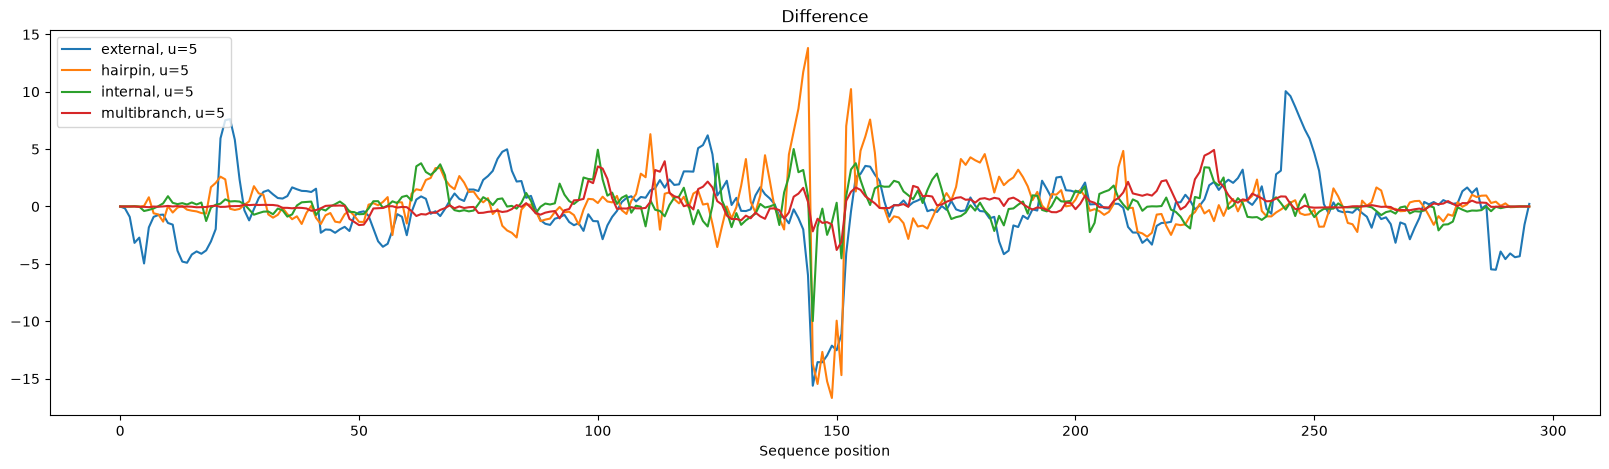

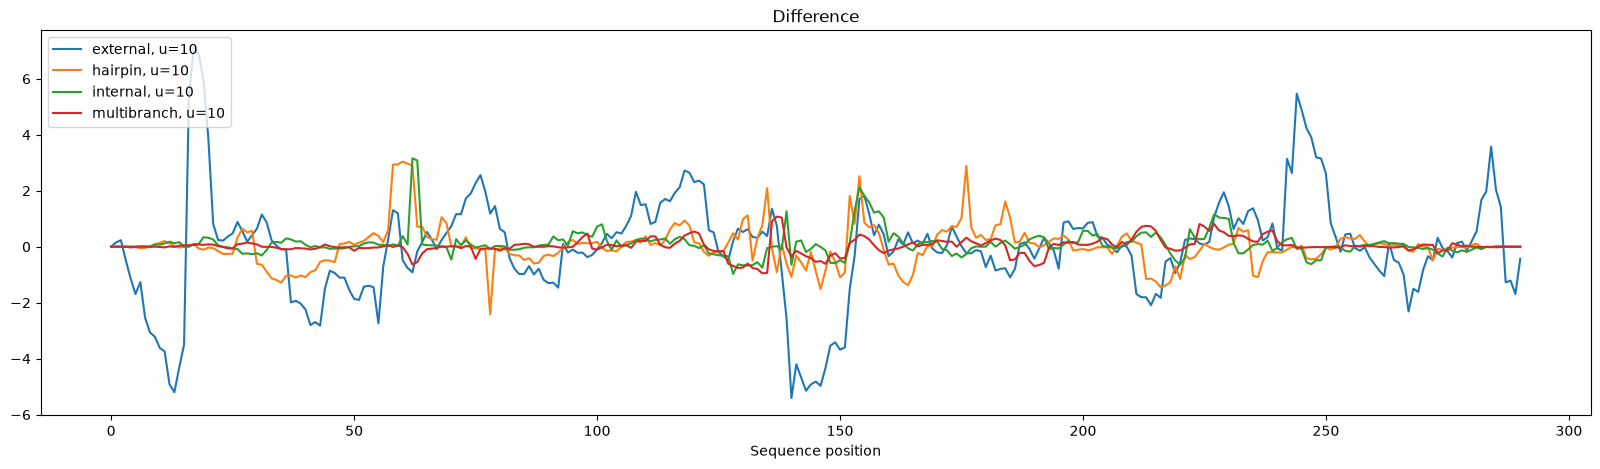

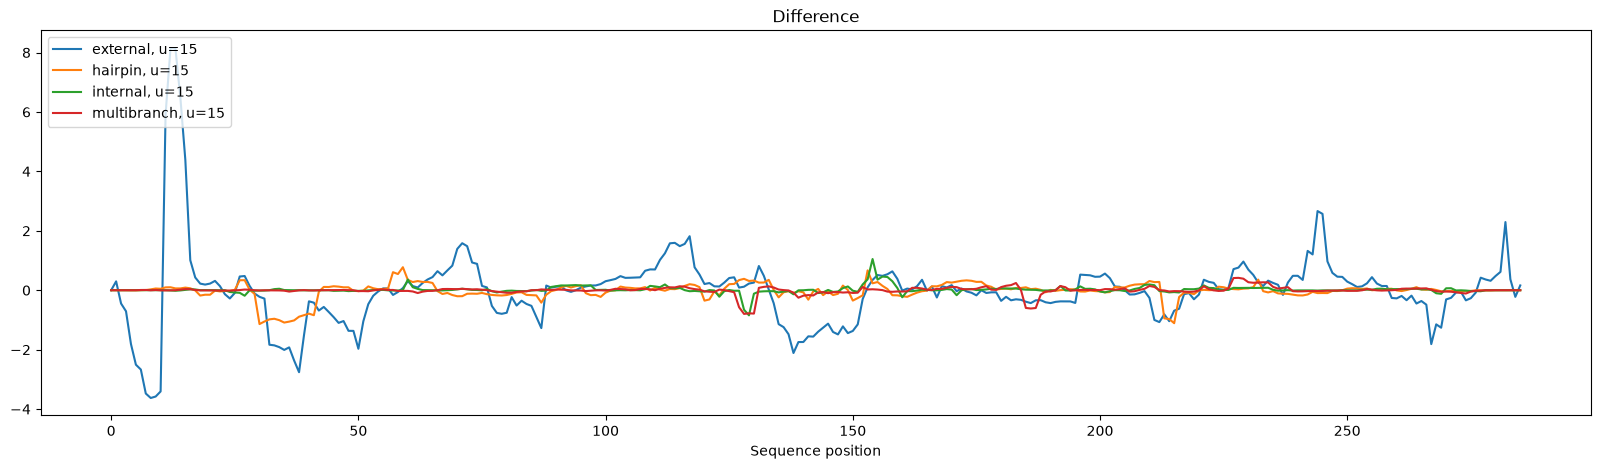

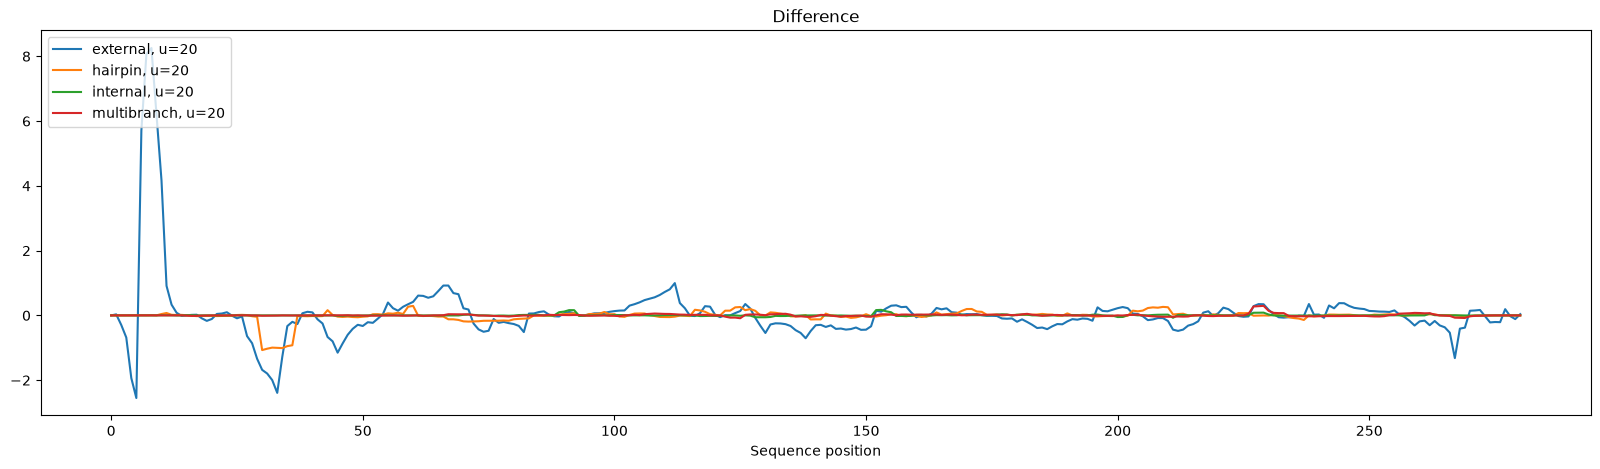

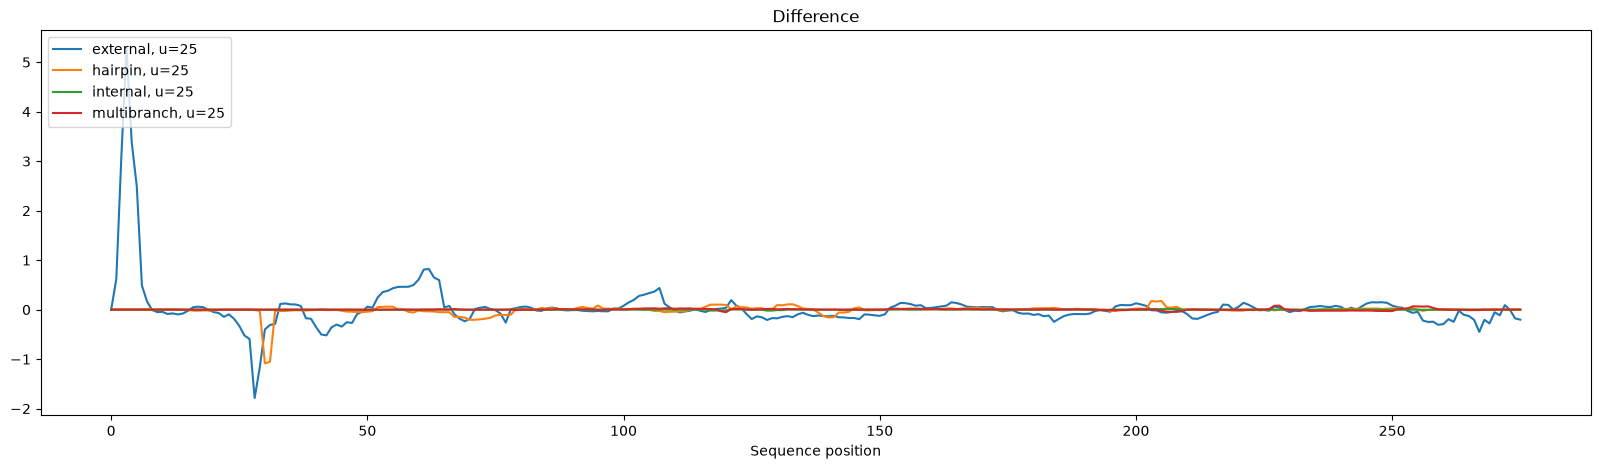

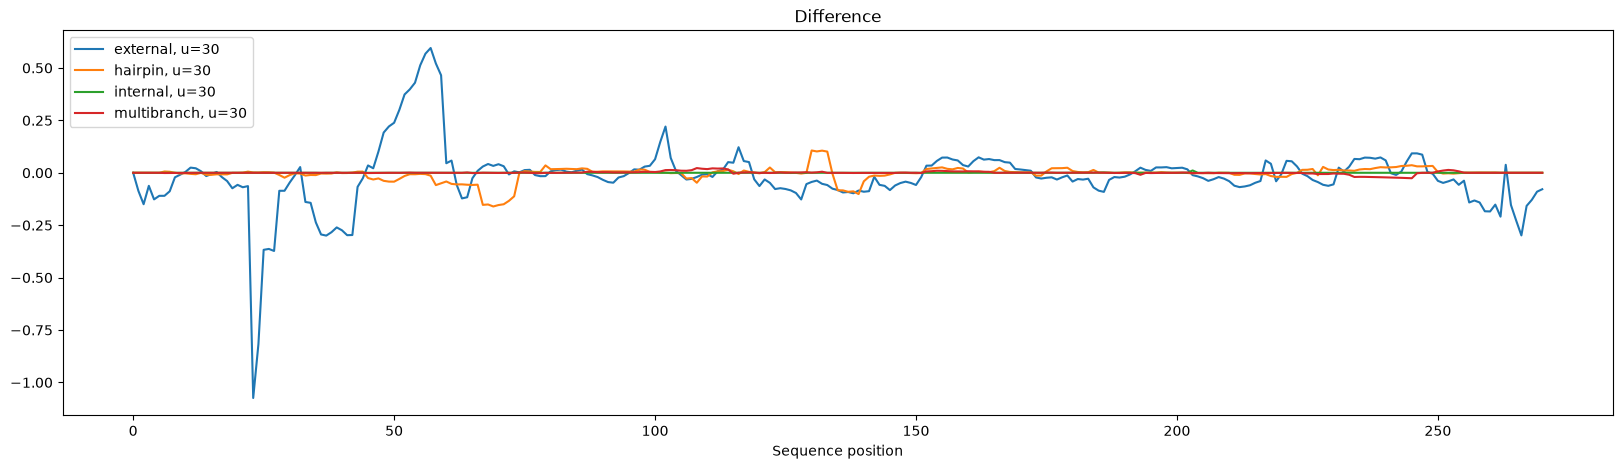

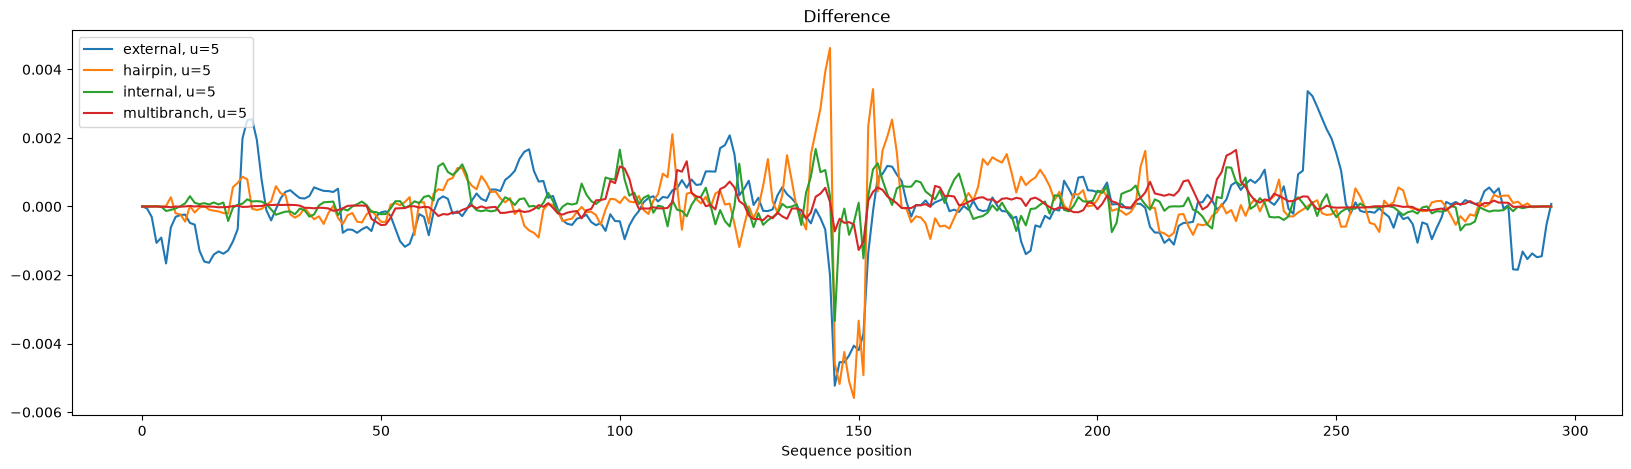

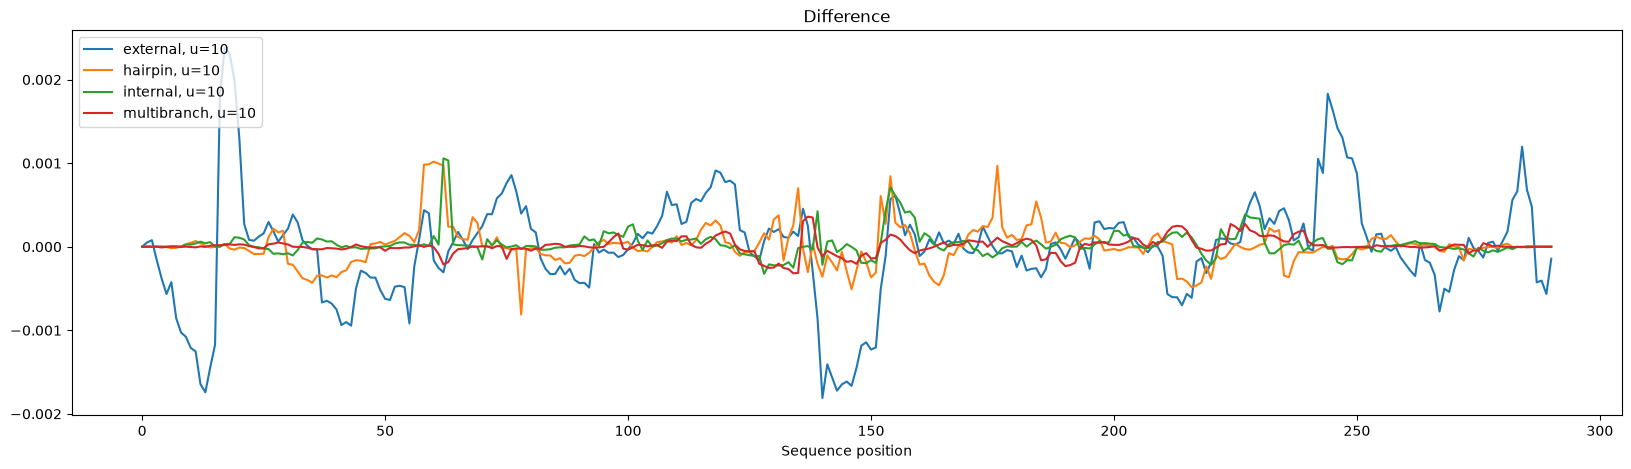

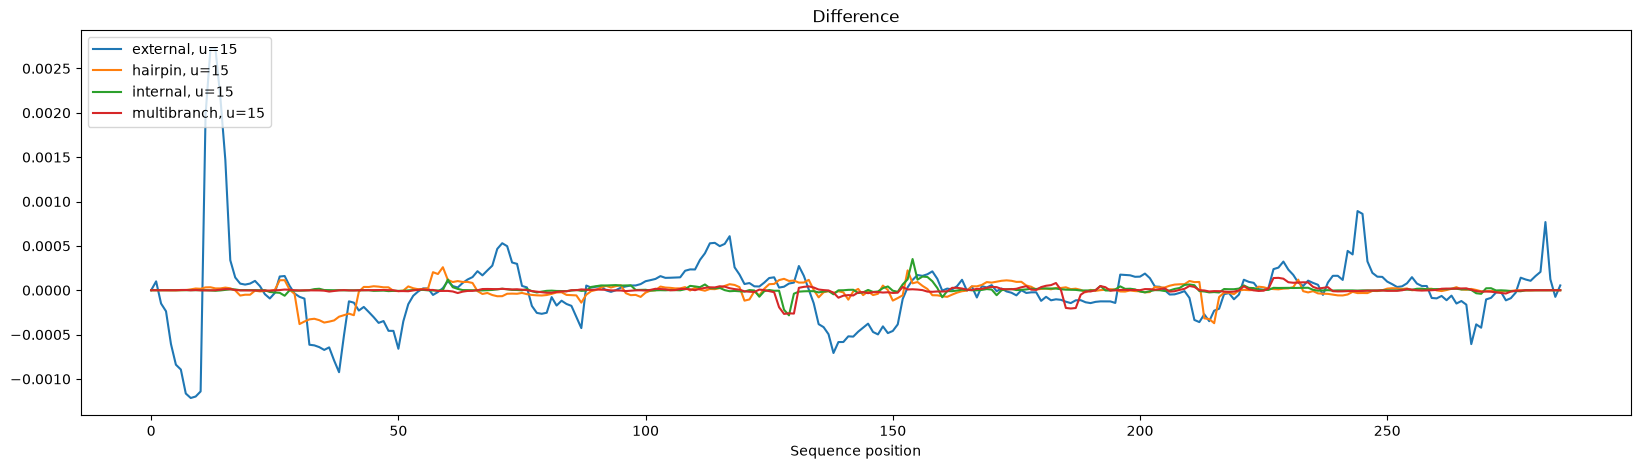

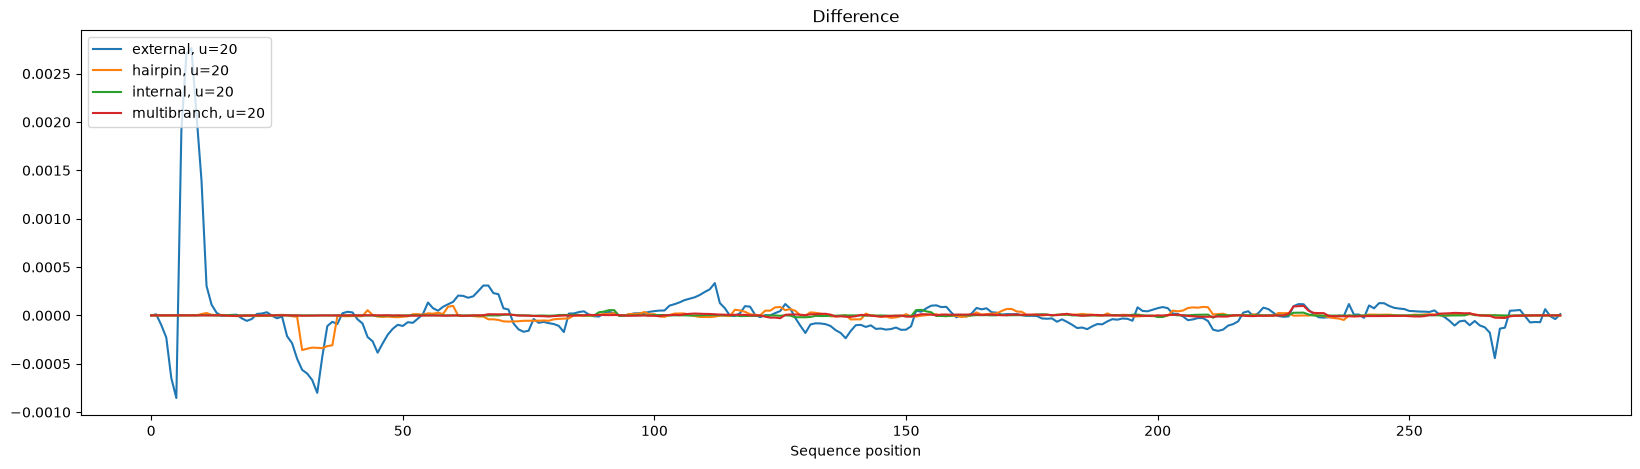

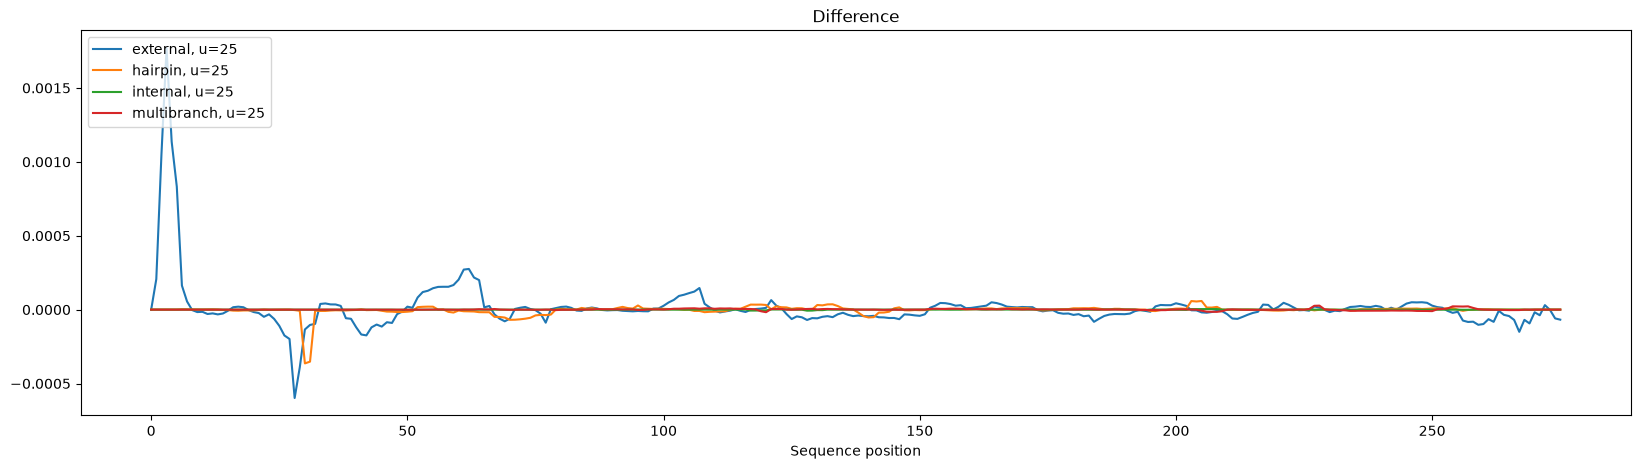

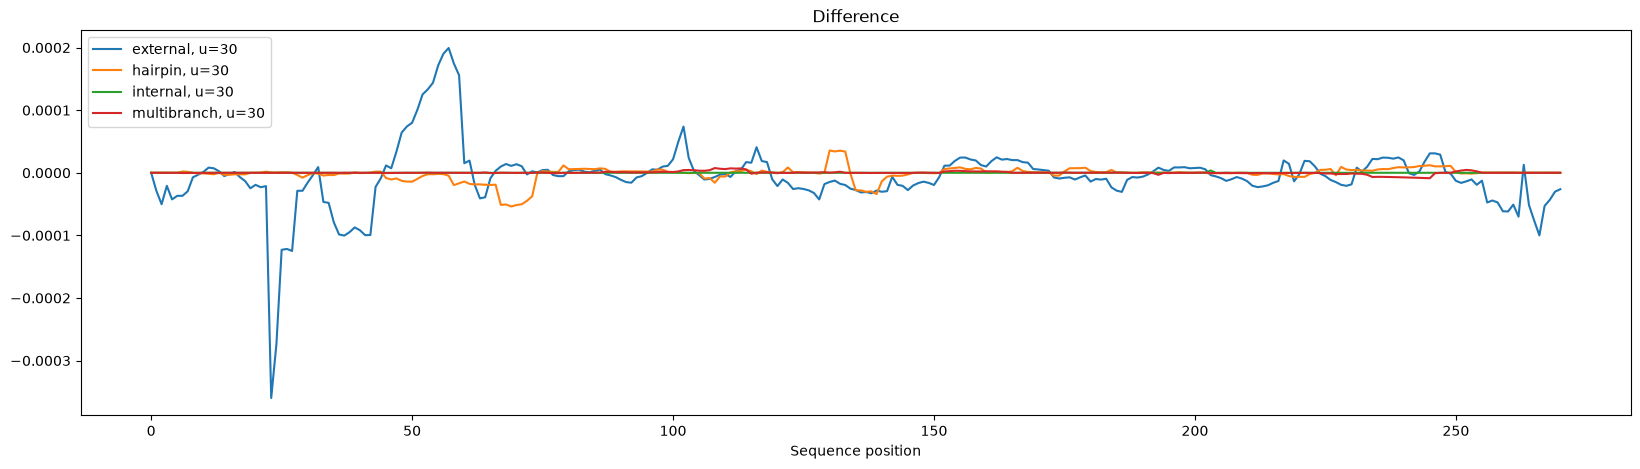

In [8]:
for footprint in accumulated_diff_data:
    fig, axs = plt.subplots(figsize = (20, 5))

    for looptype, values in accumulated_diff_data[footprint].items():
        axs.plot([i for i in range(len(values))], values, label = "{}, u={:d}".format(looptypes[looptype], footprint))
    axs.set_title("Difference")
    axs.set_xlabel("Sequence position")
    axs.legend(loc="upper left")
    
for footprint in average_diff_data:
    fig, axs = plt.subplots(figsize = (20, 5))

    for looptype, values in average_diff_data[footprint].items():
        axs.plot([i for i in range(len(values))], values, label = "{}, u={:d}".format(looptypes[looptype], footprint))
    axs.set_title("Difference")
    axs.set_xlabel("Sequence position")
    axs.legend(loc="upper left")

NM_178857.6_exon
8014
[1688, 1707, 1770, 2658, 5402, 5412, 5429]
1438
5679


/tmp/ipykernel_6259/506126919.py:136: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


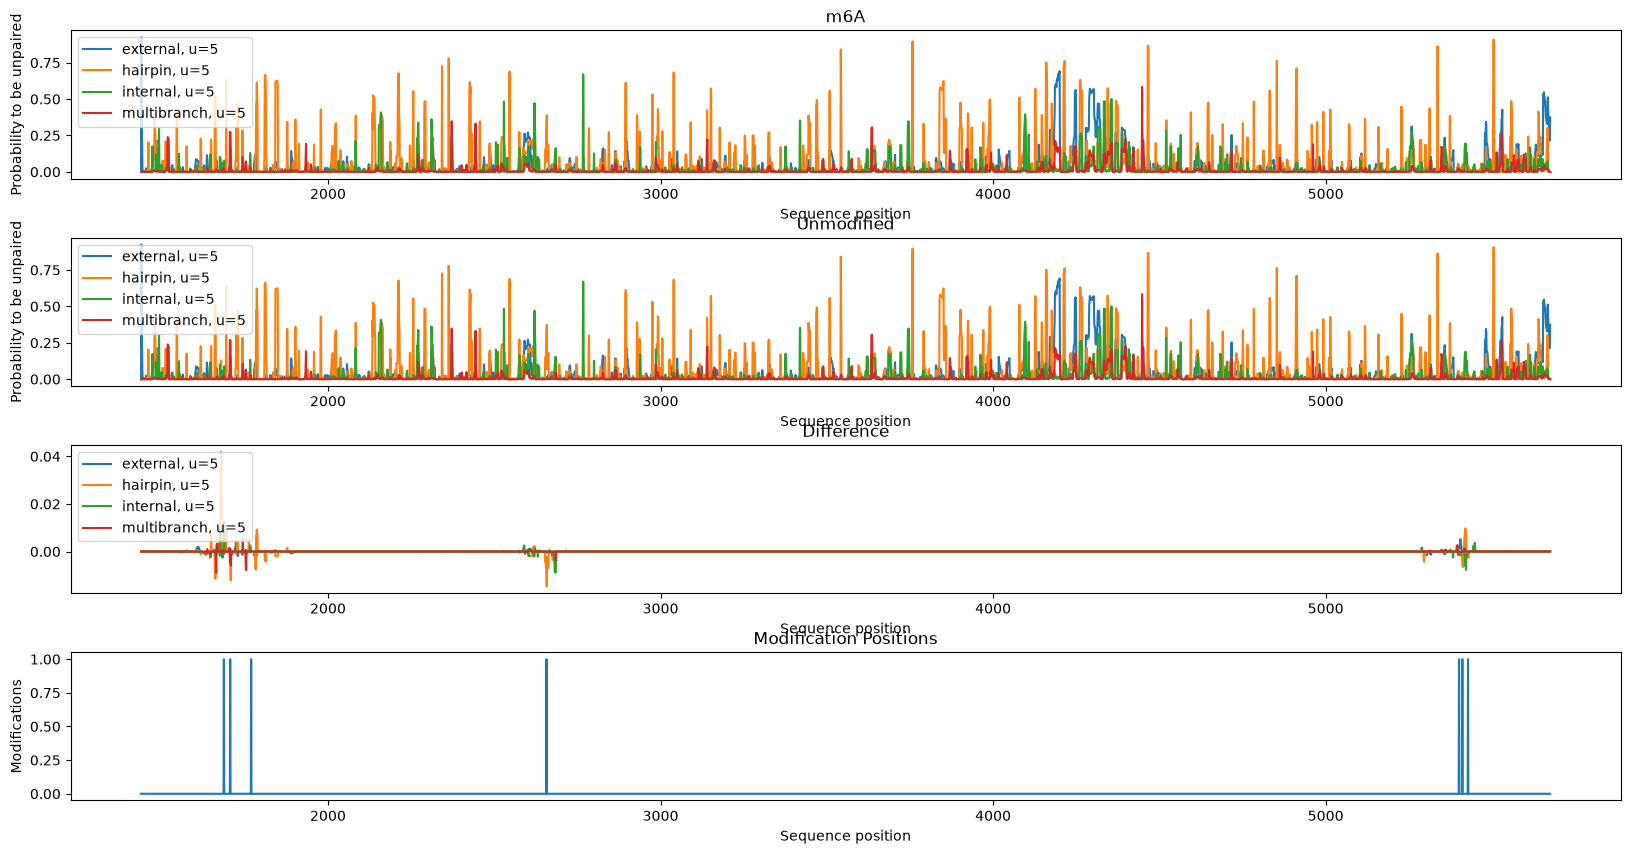

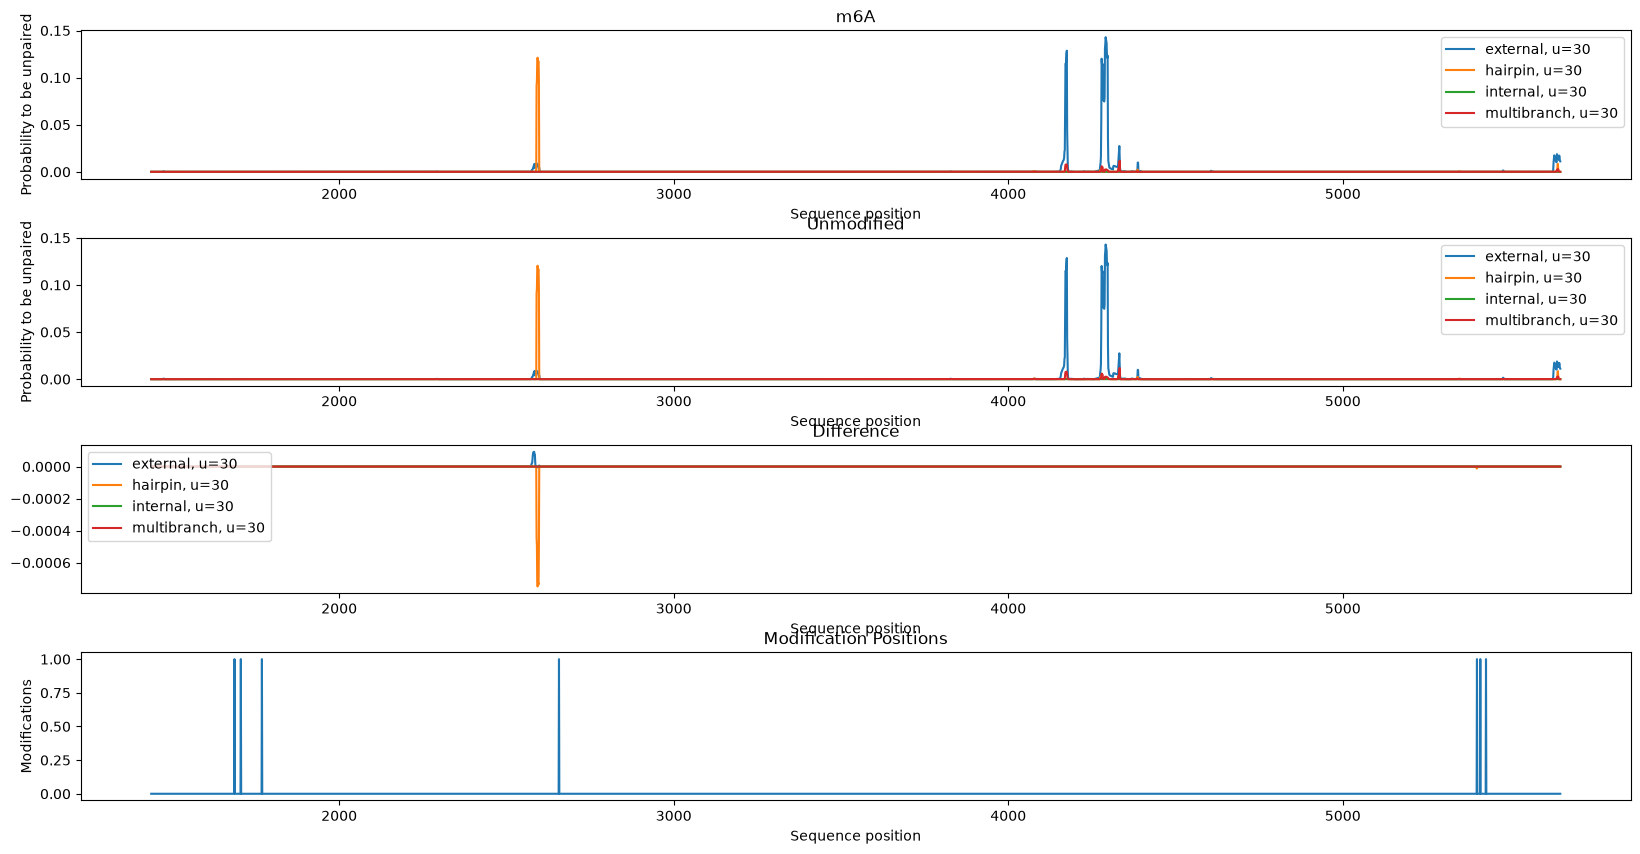

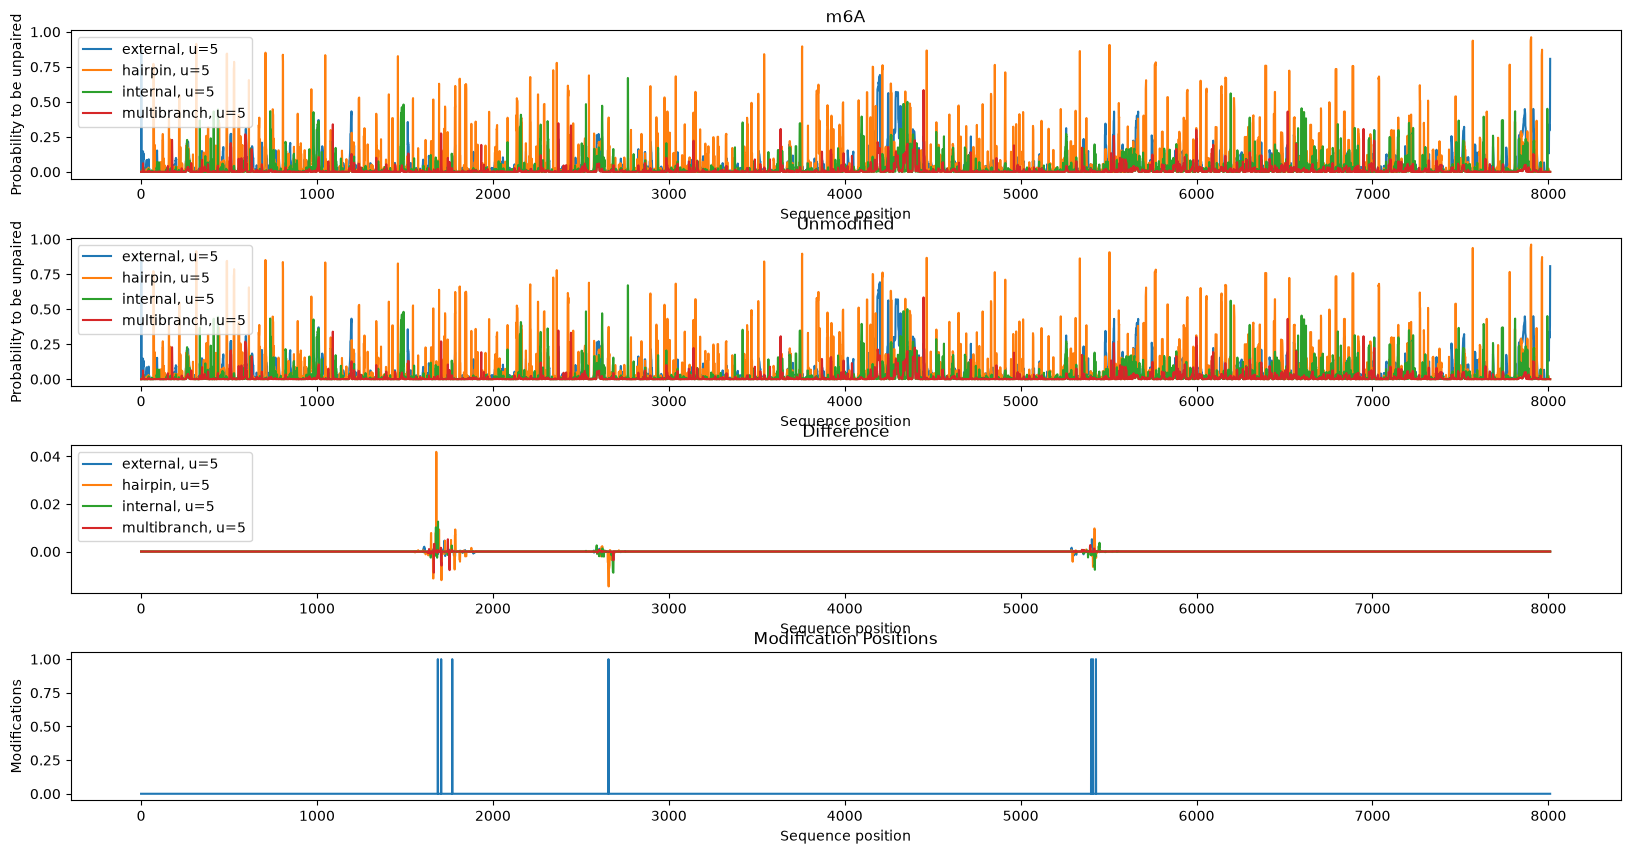

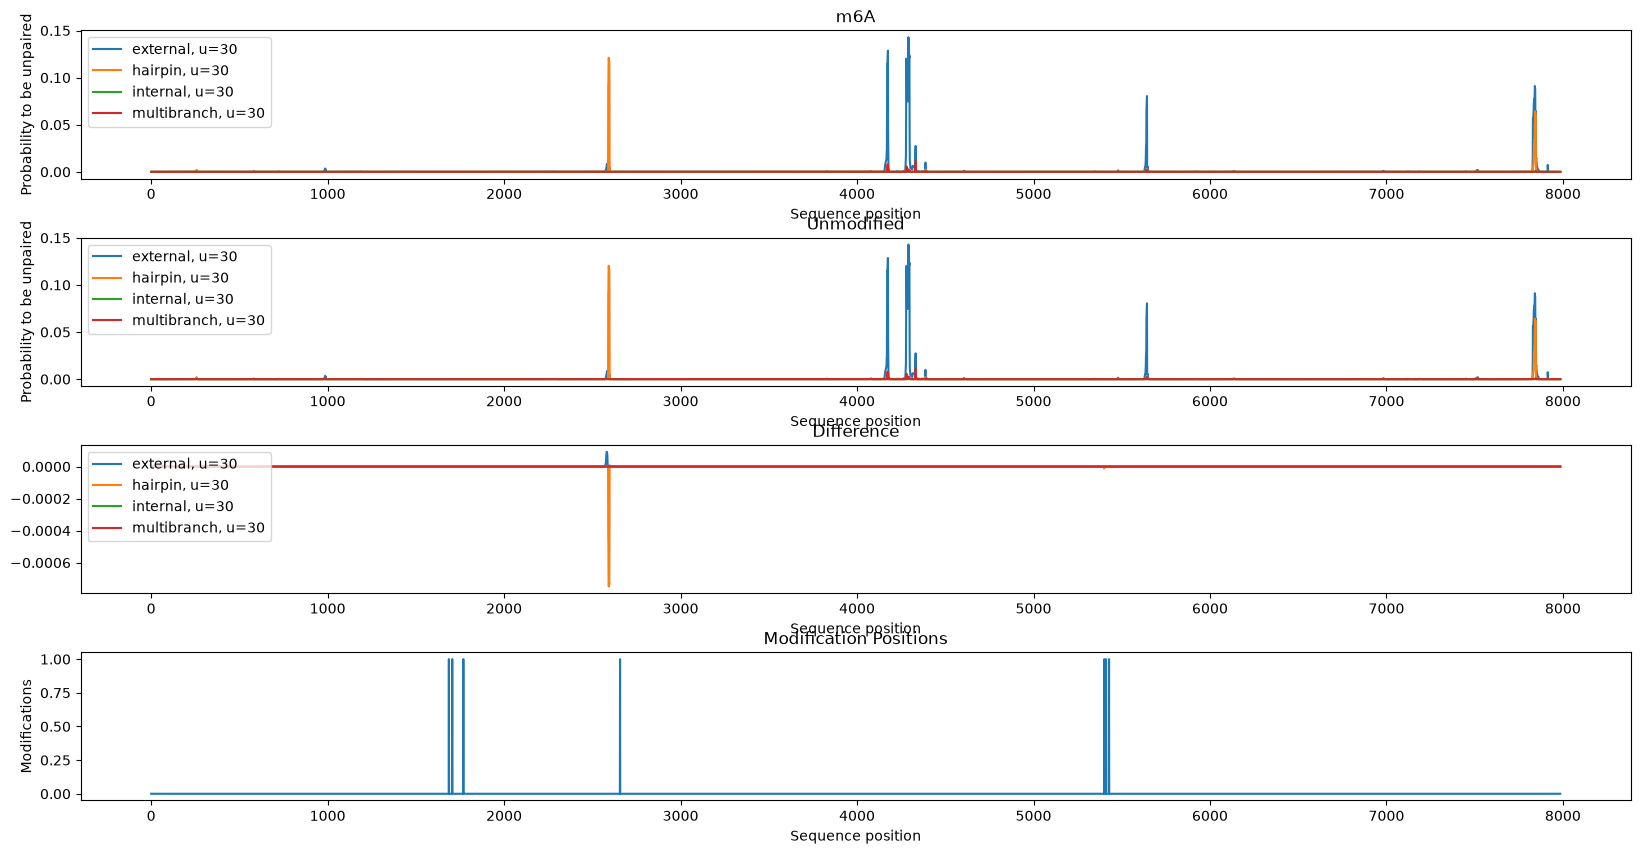

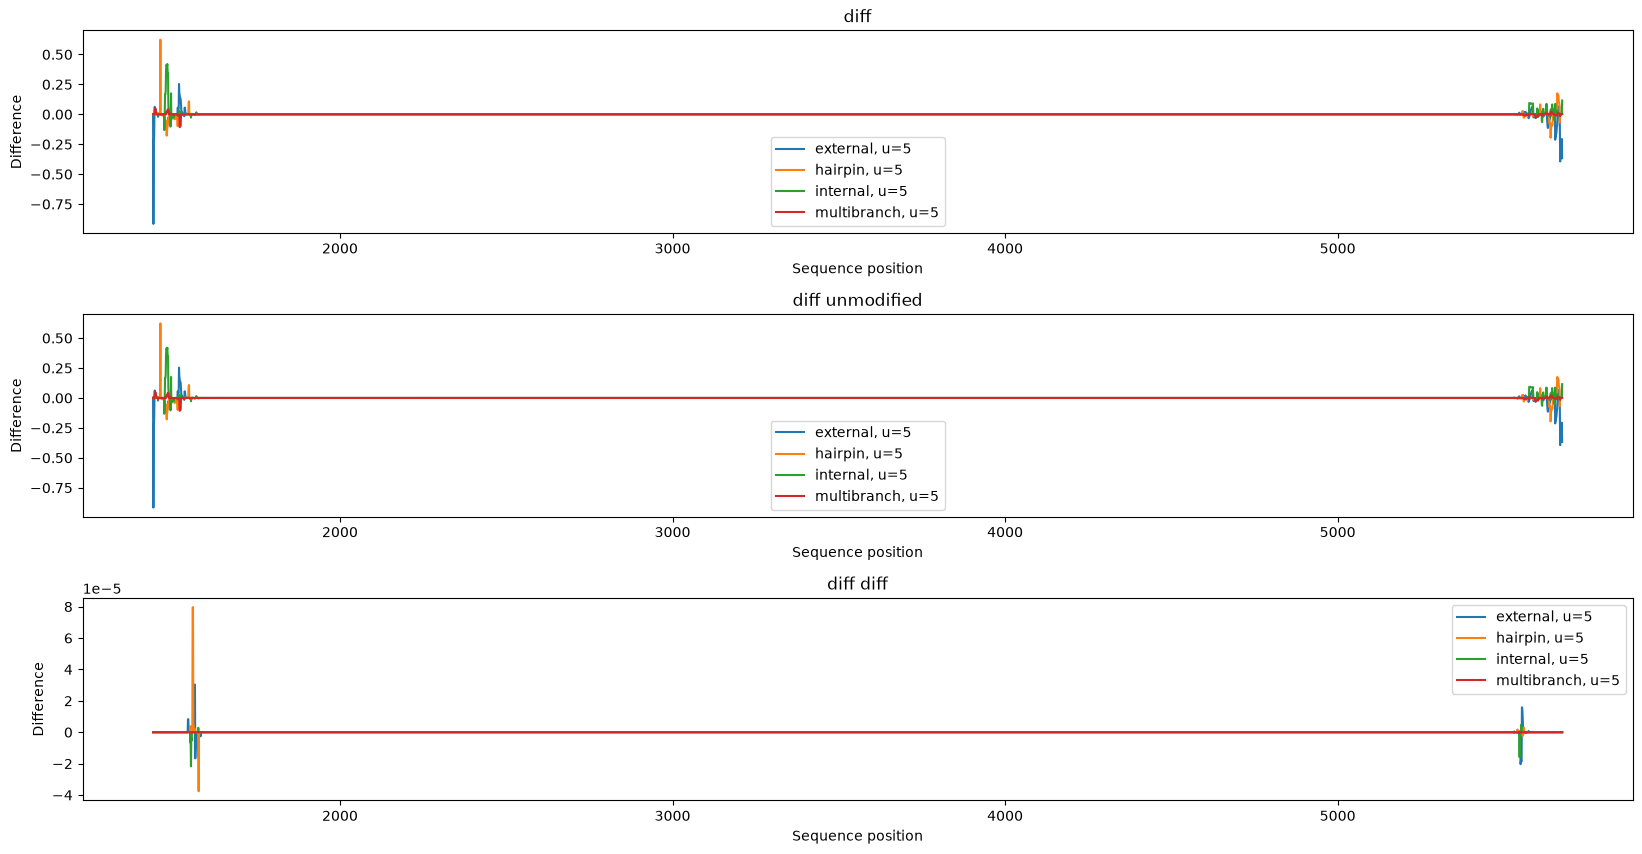

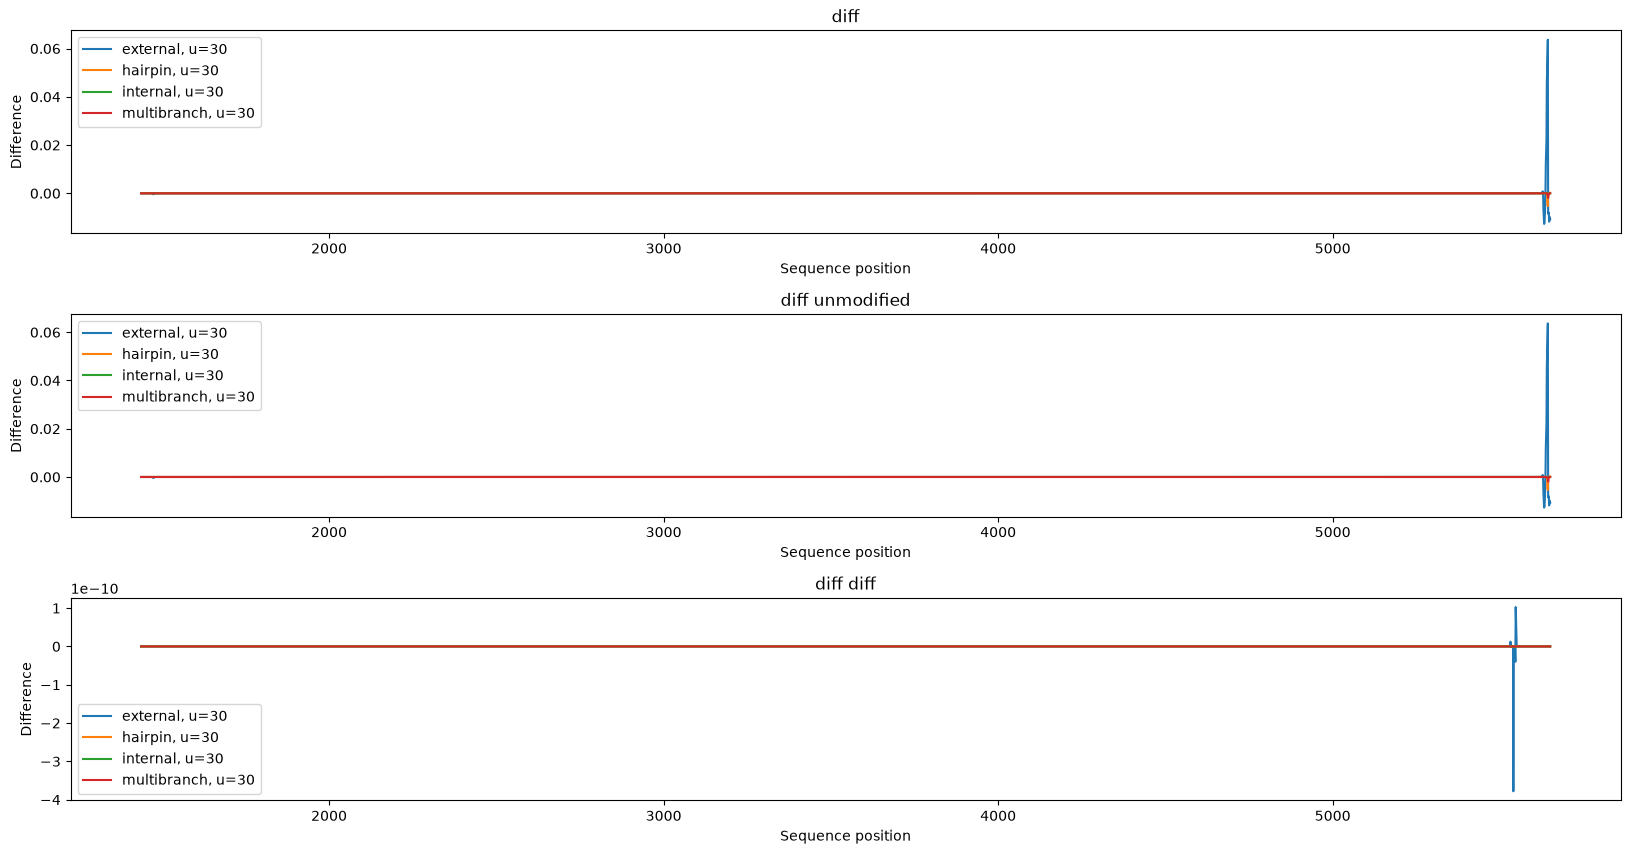

In [48]:
from mypython.algorithms import accessibility, looptypes
from mypython.plot import plot_accessibilities
from fasta import FASTA
from src.util import load_region_modifications
from src.files.files import get_files
import matplotlib.pyplot as plt

fastaFile = get_files().get_assembled_region_fasta_files().get_exons_file()
fastaFile.open_or_recompute()

file = FASTA(fastaFile.get_possibly_gzip_path())
regions = load_region_modifications(get_files().get_assembled_region_local_intersects_assembled_files().get_exons_file())

footprints = [5, 30]
windowsize = 150
L = 100

slice_mult = 2

def map_entry(entry):
    region_name = entry.name[:entry.name.find(":")]
    sequence = str(entry.seq).upper().replace("T", "U")

    modifications = []
    
    if region_name in regions:
        modifications = regions[region_name].modifications

    return (region_name, sequence, modifications)

def filter_entry(entry):
    return len(entry[2]) != 0

def filter_length(entry):
    length = len(entry[1])
    return length > 8000 and length < 9000

def filter_start(entry):
    start = max(0, entry[2][0] - 2 * windowsize)
    return start != 0

def filter_end(entry):
    end = min(len(entry[1]), entry[2][len(entry[2]) - 1] + 2 * windowsize)
    return end != len(entry[1])

modified_regions =  filter(filter_end, filter(filter_start, filter(filter_length, filter(filter_entry, map(map_entry, file)))))

for _ in range(0):
    next(modified_regions)

for region_name, sequence, modifications in modified_regions:
    print(region_name)
    print(len(sequence))

    modifications = [x + 1 for x in modifications]
    print(modifications)

    start = max(0, modifications[0] - int(windowsize * slice_mult - 50))
    #start = 0
    end = min(len(sequence), modifications[len(modifications) - 1] + int(slice_mult * windowsize - 50))
    #end = len(sequence)
    
    sequence_slice = sequence[start:end]
    modifications_slice = [x - start for x in modifications]
    print(start)
    print(end)
    data_slice_unmod = accessibility(sequence_slice, footprints, windowsize = windowsize, L = L)
    data_slice = accessibility(sequence_slice, footprints, windowsize = windowsize, L = L, m6A_sites = modifications_slice)

    plot_accessibilities(sequence_slice, footprints, looptypes, start, end, data_slice, data_slice_unmod, modifications_slice)

    data_unmod = accessibility(sequence, footprints, windowsize = windowsize, L = L)
    data = accessibility(sequence, footprints, windowsize = windowsize, L = L, m6A_sites = modifications)
    
    plot_accessibilities(sequence, footprints, looptypes, 0, len(sequence), data, data_unmod, modifications)

    diff_data_unmod = {}
    diff_data = {}
    diff_data_diff = {}

    for footprint in footprints:
        diff_fp_data_unmod = {}
        diff_fp_data = {}
        diff_fp_data_diff = {}
        for looptype in looptypes:
            diff_fp_data_unmod[looptype] = [0.0 for x in data_slice[footprint][looptype]]
            diff_fp_data[looptype] = [0.0 for x in data_slice[footprint][looptype]]
            diff_fp_data_diff[looptype] = [0.0 for x in data_slice[footprint][looptype]]
            
            for i in range(len(data_slice[footprint][looptype])):
                value = data[footprint][looptype][i + start]
                value_unmod = data_unmod[footprint][looptype][i + start]

                value_slice = data_slice[footprint][looptype][i]
                value_slice_unmod = data_slice_unmod[footprint][looptype][i]

                diff = value_unmod - value
                diff_slice = value_slice_unmod - value_slice
                
                diff_value = value - value_slice
                diff_value_unmod = value_unmod - value_slice_unmod

                diff_diff = diff - diff_slice

                diff_fp_data_unmod[looptype][i] = diff_value_unmod
                diff_fp_data[looptype][i] = diff_value
                diff_fp_data_diff[looptype][i] = diff_diff

        diff_data[footprint] = diff_fp_data
        diff_data_unmod[footprint] = diff_fp_data_unmod
        diff_data_diff[footprint] = diff_fp_data_diff

    
    for footprint in footprints:
        fig, axs = plt.subplots(3, sharey = False, figsize = (20, 10))
        for k, v in diff_data[footprint].items():
            axs[0].plot([i + start for i in range(len(sequence_slice) + 1 - footprint + 1)], v, label = "{}, u={:d}".format(looptypes[k], footprint))
        axs[0].set_title("diff")
        axs[0].set_xlabel("Sequence position")
        axs[0].set_ylabel("Difference")
        axs[0].legend()
        for k, v in diff_data_unmod[footprint].items():
            axs[1].plot([i + start for i in range(len(sequence_slice) + 1 - footprint + 1)], v, label = "{}, u={:d}".format(looptypes[k], footprint))
        axs[1].set_title("diff unmodified")
        axs[1].set_xlabel("Sequence position")
        axs[1].set_ylabel("Difference")
        axs[1].legend()
        for k, v in diff_data_diff[footprint].items():
            axs[2].plot([i + start for i in range(len(sequence_slice) + 1 - footprint + 1)], v, label = "{}, u={:d}".format(looptypes[k], footprint))
        axs[2].set_title("diff diff")
        axs[2].set_xlabel("Sequence position")
        axs[2].set_ylabel("Difference")
        axs[2].legend()

        fig.subplots_adjust(hspace=0.4)
        fig.show()
    break